# Assignment 10 — Gated Architectures: LSTMs & GRUs

### Due: Monday, Apr 6, before class

Name(s): Chang Min Bark<br>
Course: CSCI 357 - AI and Neural Networks<br>
Section: 01 - 1:00pm<br>
Semester: Spring 2026<br>
Instructor: Prof. King<br>

### References

- Hochreiter, S., & Schmidhuber, J. (1997). Long short-term memory. *Neural Computation*, 9(8), 1735–1780.
- Cho, K., et al. (2014). Learning phrase representations using RNN encoder–decoder for statistical machine translation. *EMNLP 2014*.
- Chung, J., et al. (2014). Empirical evaluation of gated recurrent neural networks on sequence modeling. *NIPS 2014 Deep Learning Workshop*.

In [1]:
import sys
import os
import time
from enum import Enum

import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset
from torch.nn.utils.rnn import pad_sequence
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, classification_report

# Basic configuration
torch.manual_seed(42)
np.random.seed(42)
sns.set_theme(style="whitegrid")

print(f"PyTorch version: {torch.__version__}")

PyTorch version: 2.10.0+cu128


In [2]:
from IPython.display import HTML, display

# Define CSS styles in a string variable for reuse across cells
css_styles = """
<style>
.todo-box {
    background-color: #fcf8e3;
    color: #000000;
    border-left: 6px solid #f0ad4e;
    padding: 10px;
    margin-bottom: 0;
}

.todo-box h3 {
    margin-top: 0;
}

.note-box {
    background-color: #d1ecf1;
    color: #000000;
    border-left: 6px solid #0c5460;
    padding: 10px;
    margin-bottom: 0;
}

.warning-box {
    background-color: #f8d7da;
    color: #000000;
    border-left: 6px solid #721c24;
    padding: 10px;
    margin-bottom: 0;
}

.section-box {
    background-color: rgb(125, 233, 150);
    color: #000000;
    border-left: 6px solid #155724;
    padding: 10px;
    margin-bottom: 0;
}
</style>
"""

display(HTML(css_styles))

In [ ]:
def show_todo(todo_text):
    display(HTML(f"""
    <div class="todo-box">
    <h2>TODO: {todo_text}</h2>
    </div>
    """))

def show_note(note_text):
    display(HTML(f"""
    <div class="note-box">
    <h2>NOTE:</h2>
    <h4>{note_text}</h4>
    </div>
    """))

def show_warning(warning_text):
    display(HTML(f"""
    <div class="warning-box">
    <h2>WARNING:</h2>
    <h3>{warning_text}</h3>
    </div>
    """))

def show_section(section_text = ""):
    display(HTML(f"""
    <div class="section-box">
    <h1>{section_text}</h1>
    </div>
    """))

In [4]:
show_todo("Set Run Configuration")

# **Notebook Run Configuration**

As most of you have already discovered, you will frequently need to re-run your notebooks from scratch. As our models and data become larger and more complex, code cells that execute training can take a lot of time. Thus, once you have finish a cell that needs to train, you might want to just execute a few epochs, or perhaps NO epochs.

* Set the variable `RUN_TRAINING_MODE` below to one of the three enumerations, then write your code to conditionally set the number of epoch to run
* Set `DO_WANDB_LOGGING` to True when you are ready to log your results.

It's up to you to properly use these constants in your code to make it easy to rerun a notebook from scratch.

In [ ]:
class RunTrainingMode(Enum):
    NONE = "NONE"
    QUICK = "QUICK"
    FULL = "FULL"

RUN_TRAINING_MODE = RunTrainingMode.FULL
DO_WANDB_LOGGING = True

# **Set up accelerator device**
> This code will create three variables
> * `cpu_device` - the default device all tensors are stored on when not explicity moving over to a GPU
> * `has_accel` - bool - `True` if you have a GPU, `False` otherwise.
> * `accel_device` - your accelerator device if you have a GPU, or set to `cpu_device` if no GPU is present to prevent exceptions if trying to run on a GPU when one is not available.


In [ ]:
cpu_device = torch.device("cpu")

# True if *some* accelerator is available (CUDA, MPS, etc.)
has_accel = torch.accelerator.is_available()
print(f"Accelerator available: {has_accel}")

# A torch.device representing the preferred accelerator (if any). If none available, set it to "cpu"
if has_accel:
    accel_device = torch.accelerator.current_accelerator()
    print(f"Preferred accelerator: {accel_device}")
else:
    accel_device = cpu_device
    print("No accelerator available, defaulting to CPU.")

Accelerator available: True
Preferred accelerator: cuda


In [7]:
# Are we running from colab?
IN_COLAB = 'google.colab' in sys.modules

if IN_COLAB:
    print("Running in Google Colab")
else:
    print("Not running in Google Colab")

Running in Google Colab


In [8]:
show_todo("Set Project Path and Install Packages")

**TODO:** You need to set `project_path` to be the root path of your project. This needs to be done regardless if whether you are running from Colab or not. I included an example that works on my machine when running locally, and setting a Drive path when running from Google Colab.

In [9]:
if IN_COLAB:
    from google.colab import drive
    drive.mount('/content/drive')
    print("Drive mounted successfully!")

    # DONE: Replace this with your Google Drive path to your project root. Below is an example:
    PROJECT_PATH = '/content/drive/My Drive/2026 SS/CSCI357/csci357_2026sp'

    # Confirm the project_path exists, raise an error if not
    if not os.path.exists(PROJECT_PATH):
        raise FileNotFoundError(f"Project path NOT FOUND: \"{PROJECT_PATH}\"")
    else:
        print(f"Confirmed: Project path exists at \"{PROJECT_PATH}\"")
else:
    # DONE: Replace this with your project root.
    PROJECT_PATH = '/content/drive/My Drive/2026 SS/CSCI357/csci357_2026sp'

print(f"Project path: \"{PROJECT_PATH}\"")
if PROJECT_PATH not in sys.path:
    sys.path.append(PROJECT_PATH)
    sys.path.append(PROJECT_PATH + "/src")

# Ensure that the current working directory is PROJECT_PATH
if os.getcwd() != PROJECT_PATH:
    print(f"Changing working directory to project path: \"{PROJECT_PATH}\"")
    os.chdir(PROJECT_PATH)
else:
    print(f"Already in the correct working directory: \"{PROJECT_PATH}\"")

Mounted at /content/drive
Drive mounted successfully!
Confirmed: Project path exists at "/content/drive/My Drive/2026 SS/CSCI357/csci357_2026sp"
Project path: "/content/drive/My Drive/2026 SS/CSCI357/csci357_2026sp"
Changing working directory to project path: "/content/drive/My Drive/2026 SS/CSCI357/csci357_2026sp"


In [10]:
show_todo("Add yfinance support!")

### Add `yfinance` support in `pyproject.toml`

For this project, you will need to install the `yfinance` package. 
`yfinance` is a Python library that allows you to easily download historical market data from Yahoo! Finance.
We'll use it to fetch daily stock price data for the applied time series section.
To make sure `yfinance` is installed whenever your environment is set up, 
add it to your project's `pyproject.toml` file under the `[project]` dependencies section, like so:

```
  [project]
  dependencies = [
      ...
      "yfinance",
  ]
```

If you are running locally, after updating `pyproject.toml`, run:
```
  uv pip install -e .
```

If you are running in Colab, the next cell will update your environment.


In [11]:
# Install any packages that are not part of the standard Google Colab environment
if IN_COLAB:
    # Install uv for fast installs (-q for quiet, -U for update)
    !pip install -qU uv
    # Install project dependencies and local code in editable mode,
    !uv pip install -e .
    print("Colab install commands are provided above; uncomment to run them.")
else:
    print("Running locally, assuming project dependencies installed in your local environment.")

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 24.6/24.6 MB 97.8 MB/s eta 0:00:00:00:0100:01
Using Python 3.12.13 environment at: /usr
Resolved 220 packages in 1.19s                                       
Prepared 23 packages in 2.41s                                            
Uninstalled 5 packages in 421ms
Installed 23 packages in 80ms                               
 + asttokens==3.0.1
 + async-lru==2.3.0
 - decorator==4.4.2
 + decorator==5.2.1
 + executing==2.2.1
 - ipython==7.34.0
 + ipython==9.12.0
 + ipython-pygments-lexers==1.1.1
 + jedi==0.19.2
 + json5==0.14.0
 + jupyter==1.1.1
 + jupyter-lsp==2.3.1
 + jupyterlab==4.5.6
 + jupyterlab-server==2.28.0
 + lantern==0.1.0 (from file:///content/drive/My%20Drive/2026%20SS/CSCI357/csci357_2026sp)
 + lightning-utilities==0.15.3
 + pure-eval==0.2.3
 + pydeck==0.9.1
 - scipy==1.16.3
 + scipy==1.13.1
 + stack-data==0.6.3
 + streamlit==1.56.0
 + torchmetrics==1.9.0
 - traitlets==5.7.1
 + traitlets==5.14.3
 - transformers==5.0.0
 + transformer

In [ ]:
# Testing... only uncomment to force a hard restart of the kernel in Colab
if IN_COLAB:
    # import os
    # # Send signal 9 (SIGKILL) to the current process ID to force a hard restart
    # os.kill(os.getpid(), 9)
    pass

In [13]:
# Once packages are installed, we can kill the kernel to force a restart. Just restart the kernel
if IN_COLAB:
    try:
        import lantern
        print(lantern.__file__)
        print("Success!")
    except Exception as e:
        print("Might need to restart your kernel.")
        # This will force the kernel to restart
        # import os
        # os.kill(os.getpid(), 9)

/content/drive/My Drive/2026 SS/CSCI357/csci357_2026sp/src/lantern/__init__.py
Success!


In [14]:
# This cell loads the 'autoreload' extension for IPython/Jupyter, which automatically reloads any modules
# you import whenever their code changes on disk. The first line loads the extension, and the second line
# sets autoreload to mode 2, which reloads all modules (except those excluded by %aimport) before each execution.
# This is especially useful when you're actively developing Python modules in separate files and want
# changes to be picked up immediately without restarting the notebook kernel.
# The 'imp' module is deprecated in Python 3.4 and removed in Python 3.12. Newer IPython/Jupyter versions
# of autoreload should not need it. Removing the install command.
#
# Turn on the "Auto-Updater"
%load_ext autoreload
%autoreload 2

In [ ]:
import wandb

In [16]:
show_todo("Set W&B Configuration Variables")

# Set your identity variables for W&B!

Fill in the following variables below to ensure your data is properly logged to Weights & Biases

In [17]:
# DO NOT CHANGE THIS:
entity = "bucknell-university-csci357-2026sp"

# DONE: Fill in your name, user id, and email
user_name = "Chang Min Bark"
user_initials = "CMB"
user_id = "cb073"
user_email = "cb073@bucknell.edu"

# Authenticate with Hugging Face

Assuming that you already created your Hugging Face account and set up your token (see hw08), authenticate with Hugging Face. If you are running on Colab, you were instructed to store your token in a secret. This section assumes you set that up.

In [ ]:
if IN_COLAB:
    from google.colab import userdata
    from huggingface_hub import login

    login(token="")

# Import Engine Modules

We import our `my_engine` package components here. Everything you built in hw09 — `RNNModel`, `TextRNNModel`, `TimeSeriesDataset`, regression metrics, the `rnn_type` config switch — is already in your engine. This week you will **use** these tools, not rebuild them.

In [19]:
from lantern.config import ModelConfig, TrainerConfig, MetricsConfig
from lantern.utils import build_model, make_optimizer
from lantern.trainer import Trainer
from lantern.data import get_dataloaders, get_hf_text_dataset, get_ucimlrepo_np_arrays, TimeSeriesDataset
from lantern.text import text_collate_fn
from lantern.sweep import make_train_sweep

In [20]:
show_section("Background")

# Background

## Overview

In hw09, you built a complete RNN pipeline: `RNNModel`, `TextRNNModel`, `TimeSeriesDataset`, regression metrics, and you trained on both a synthetic time series and IMDB sentiment. You also observed two critical phenomena:

1. **Vanishing gradients** — gradient norms decayed exponentially as sequence length increased
2. **Exploding gradients** — pre-clipping gradient norms grew unboundedly with high learning rates

If you completed Challenge 5, you saw something tantalizing: switching from `rnn_type="rnn"` to `rnn_type="lstm"` dramatically improved performance on the Long Echo task. The LSTM maintained low loss at sequence lengths of 50 and 100 where the vanilla RNN completely failed. But *why*?

This week, we answer that question. We formally study **gated architectures** — the LSTM and GRU — that solve the vanishing gradient problem through a structural innovation: **learned gates** that control the flow of information through time. By the end of this assignment, you will understand the gate equations, know when to use each architecture, and have applied them to both text classification and real-world time series forecasting.

## 1. Why Vanilla RNNs Forget: A Brief Review

Let's briefly discuss the math the basic RNN. Recall the vanilla RNN update equation from hw09:

$$h_t = \tanh(W_{ih} x_t + W_{hh} h_{t-1} + b_h)$$

The hidden state $h_t$ has a dual role. It serves as:
* the **memory** of the past (carrying information forward)
* the **output** at the current step (producing useful representations)

Every piece of information that enters the hidden state must pass through the same $\tanh$ nonlinearity and the same weight matrix $W_{hh}$ at every time step.

Training is no different than any other model we've seen, where we're using gradient descent to adjust weights in a way that leads toward a (hopefully) optimal solution with respect to the loss function. Indeed, we have the same training model here... mostly. The challenge is the recursive part of the network. Take a moment to understand how that impacts backpropagation. We're dealing with **backpropagation through time** or **BPTT**. And, during backpropagation through time, this produces a **product of Jacobians**:

> What is a Jacobian?
> 
> In calculus, when you have a function that maps a vector to another vector, the Jacobian is the matrix of all first-order partial derivatives. For a function $\mathbf{f}: \mathbb{R}^n \to \mathbb{R}^m$, the Jacobian $J$ is an $m \times n$ matrix where:
> 
> $$J_{ij} = \frac{\partial f_i}{\partial x_j}$$

In the context of RNNs, we can understand that we need to rollback the backpropagation over time. How much time? The length of the sequence that you've used to feed into the network. Thus, updating the RNN part of our network is a product of Jacobians, denoted as follows:

$$\frac{\partial \mathcal{L}}{\partial h_t} = \frac{\partial \mathcal{L}}{\partial h_T} \prod_{k=t+1}^{T} \frac{\partial h_k}{\partial h_{k-1}}$$

You can see that $\frac{\partial h_k}{\partial h_{k-1}}$ is the Jacobian of the hidden state update function. It tells us how a small change in $h_{k-1}$ affects $h_k$. For the vanilla RNN, this Jacobian involves both $W_{hh}$ and the derivative of $\tanh$.

When the **spectral norm of $W_{hh}$** (i.e. the largest singular value, or the maximum factor by which the matrix $W_{hh}$ can stretch any vector) is less than 1, then this product decays exponentially — **vanishing gradients**. The network cannot learn dependencies that span more than a few dozen time steps.

**The fundamental problem:** the hidden state has no mechanism to **selectively** remember important information, forget irrelevant information, or control what gets exposed as output. Everything is mixed together in one vector, transformed by the same operation at every step. We need a more sophisticated architecture.

### Background Check 1

**DONE:** 

**Q1:** The vanilla RNN applies the same $W_{hh}$ matrix at every time step. If a sequence is 50 steps long, why does the gradient signal from the output at step 50 fail to meaningfully update weights responsible for $h_1$? What specific property of the repeated matrix product causes this?

**Answer:**
<br>
The gradient signal from step 50 fails to meaningfully update weights for $h_1$ because the product of Jacobians exponentially decay if the spectral norm of the weight matrix is less than 1. We can think of it like multiplying a value less than 1 with itself 50 times, which can result in near 0 values. This means that the gradients of the loss function with respect to the first step is also going to be near zero.
<br>

## 2. The LSTM: Architecture and Gate Equations

**I strongly recommend that you read the article by Christopher Olah on understanding LSTMs. This is the best summary I have come across:**
* https://colah.github.io/posts/2015-08-Understanding-LSTMs/

I will only include brief summarizing information here.

The **Long Short-Term Memory** (LSTM) network was proposed by Hochreiter & Schmidhuber in 1997, specifically to address the vanishing gradient problem. The core innovation is the introduction of a **cell state** $c_t$ — a separate memory vector that runs alongside the hidden state $h_t$.

Think of the cell state as a **conveyor belt** that carries information across many time steps. Information on the conveyor belt is modified only through **addition** and **element-wise multiplication** — both of which have well-behaved gradients. This creates a near-constant gradient path through time, solving the vanishing gradient problem.

The LSTM uses four components at each time step, each controlled by learned **gates**:

### The Forget Gate — "How much of the old memory should I keep?"

$$f_t = \sigma(W_f [h_{t-1}, x_t] + b_f)$$

The forget gate produces values between 0 and 1 for each element of the cell state. A value near 1 means "keep this information"; a value near 0 means "forget it." The sigmoid ($\sigma$) ensures the output is always in $[0, 1]$.

### The Input Gate — "Which new information should I write?"

$$i_t = \sigma(W_i [h_{t-1}, x_t] + b_i)$$

The input gate decides which elements of the cell state should be updated with new information.

### The Candidate Cell — "What new information is available?"

$$\tilde{c}_t = \tanh(W_c [h_{t-1}, x_t] + b_c)$$

The candidate cell state produces a vector of potential new values (in $[-1, 1]$ via $\tanh$). Not all of this will be written — the input gate controls how much.

### The Cell State Update — The Key Equation

$$c_t = f_t \odot c_{t-1} + i_t \odot \tilde{c}_t$$

This is the heart of the LSTM. The new cell state is a **weighted combination** of:
- The old cell state (scaled by the forget gate)
- New candidate values (scaled by the input gate)

The $\odot$ symbol means **element-wise multiplication** (Hadamard product). Because this update is essentially a linear combination (no squashing nonlinearity applied to $c_t$ itself), gradients can flow through $c_t$ across many time steps without vanishing. This is why the LSTM succeeded on the Long Echo task where the vanilla RNN failed.

### The Output Gate — "What should I expose as $h_t$?"

$$o_t = \sigma(W_o [h_{t-1}, x_t] + b_o)$$

### The Hidden State

$$h_t = o_t \odot \tanh(c_t)$$

The hidden state is a filtered version of the cell state: the cell state is squashed through $\tanh$ (to $[-1, 1]$) and then gated by the output gate. This means the LSTM can store information in $c_t$ without immediately exposing it in $h_t$.

### Connection to hw09 Challenge 5

In the Long Echo task, the model had to remember the very first element $x_0$ through an arbitrarily long sequence. The vanilla RNN's hidden state was repeatedly transformed by $\tanh(W_{hh} \cdot + \dots)$, causing the memory of $x_0$ to decay exponentially. The LSTM's cell state, by contrast, can set the forget gate near 1 and the input gate near 0 for most time steps, effectively **preserving** $x_0$ on the conveyor belt until the final output. This is exactly what happened — and now you know *why*.

In [21]:
show_note("The cell state c_t is the LSTM's 'gradient highway.' Because it is updated through addition (not through a squashing nonlinearity), gradients can flow across many time steps without vanishing. This is the structural innovation that makes LSTMs work on long sequences.")

### Background Check 2

**DONE:**

**Q1:** In the LSTM cell state update $c_t = f_t \odot c_{t-1} + i_t \odot \tilde{c}_t$, what is the gradient of the loss with respect to $c_{t-1}$? Why does this allow gradients to flow more easily than through a vanilla RNN hidden state?

**Answer:**
<br>
The gradient of the loss with respect to $c_{t-1}$ is $\frac{\partial \mathcal{L}}{\partial c_t} \cdot f_t$. This allows gradients to flow more easily than through a vanilla RNN hidden state because there is no multiplicative (squashing) factor that can result in exponential decay. The gradient is scaled only by the forget gate $f_t$ directly, with no weight matrix multiplication and no saturating nonlinearity.
<br>

**Q2:** Suppose the forget gate outputs $f_t \approx 0$ for all time steps. Describe the LSTM's behavior. Under what kind of task would this be appropriate?

**Answer:**
<br>
This means that the LSTM is not remembering/using information from previous time steps. This would be appropriate for tasks where each input is independent and past context is irrelevant, such as predicting a label for each token based solely on the current input, with no dependence on prior sequence history.
<br>

## 3. PyTorch's `nn.LSTM`: What Changes from `nn.RNN`

Your `RNNModel` and `TextRNNModel` from hw09 already support `rnn_type="lstm"` — you just need to flip a config flag. But there are a few important differences from `nn.RNN`:

**Output structure:** `nn.LSTM` returns a tuple `(output, (h_n, c_n))` instead of `(output, h_n)`:
- `output`: shape `(batch, seq_len, hidden_size)` — the hidden state at every time step (same as RNN)
- `h_n`: shape `(num_layers * num_directions, batch, hidden_size)` — the final hidden state
- `c_n`: shape `(num_layers * num_directions, batch, hidden_size)` — the **final cell state**

For classification, we still use `h_n[-1]` (or concatenate `h_n[-2]` and `h_n[-1]` for bidirectional). The cell state `c_n` is internal memory — it is **not** typically used for the output.

**Parameter count:** An LSTM has roughly **4× the parameters** of an equivalently-sized vanilla RNN. This is because each of the four gates (forget, input, candidate, output) has its own weight matrix and two bias vectors (one for the input connection, one for the recurrent connection). For hidden size $d_h$ and input size $d_{in}$:
- Vanilla RNN: $d_h(d_{in} + d_h) + 2d_h$ parameters per layer
- LSTM: $4 \times [d_h(d_{in} + d_h) + 2d_h]$ parameters per layer

The $2d_h$ bias term reflects PyTorch's convention of keeping separate input-hidden and hidden-hidden biases for each gate. You can verify this with `sum(p.numel() for p in nn.LSTM(d_in, d_h).parameters())`.

**Dropout between layers:** `nn.LSTM(dropout=p)` applies dropout **between stacked layers**, not within a time step. A single-layer LSTM (`num_layers=1`) is **unaffected** by this argument. For regularizing single-layer LSTMs, apply `nn.Dropout` to the output.

## 4. The GRU: A Streamlined Alternative

The **Gated Recurrent Unit (GRU)** was introduced by Cho et al. in 2014, the same year as the influential sequence-to-sequence paper. It was designed to match LSTM performance with fewer parameters and simpler computation.

The GRU has **two gates** instead of four, and **no separate cell state**:

### Reset Gate — "How much of the past hidden state should I use?"

$$r_t = \sigma(W_r [h_{t-1}, x_t])$$

### Update Gate — "How much of the old state should I keep vs. overwrite?"

$$z_t = \sigma(W_z [h_{t-1}, x_t])$$

### Candidate Hidden State

$$\tilde{h}_t = \tanh(W [r_t \odot h_{t-1}, x_t])$$

The reset gate $r_t$ controls how much of the previous hidden state is visible when computing the candidate. When $r_t \approx 0$, the candidate ignores the past entirely.

### Hidden State Update

$$h_t = (1 - z_t) \odot h_{t-1} + z_t \odot \tilde{h}_t$$

The update gate $z_t$ interpolates between keeping the old hidden state and replacing it with the candidate. When $z_t \approx 0$, the hidden state is **copied unchanged** (like the LSTM's forget gate near 1). When $z_t \approx 1$, the state is fully overwritten.

**Key differences from the LSTM:**
- No separate cell state — the hidden state does everything
- Two gates instead of four → roughly **3× the parameters** of a vanilla RNN (vs. 4× for LSTM)
- Fewer parameters means faster training and less memory
- Often matches LSTM performance on shorter sequences; LSTM tends to edge ahead on very long sequences requiring fine-grained memory control

### Background Check 3

**Q1:** The GRU's hidden state update is $h_t = (1 - z_t) \odot h_{t-1} + z_t \odot \tilde{h}_t$. What structural property does this share with the LSTM cell state update that helps gradient flow? What important capability does the GRU give up by using a single update gate instead of separate forget and input gates?

**Answer:**
<br>
The GRU has the structural property of having no weight matrix multiplication and saturating nonlinearirty, which allows gradients to flow stabily. The important capability that the GRU gives up is the decoupling of the previous hidden/cell state and the new candidate state. Instead of having two separate gates, the same gate (and its inverse) is used.
<br>

**Q2:** You are building a model to classify 15-word product review snippets (short text) into 5 sentiment categories, running on a laptop with limited memory. Based on the rules of thumb you've read, which architecture and configuration would you start with, and why?

**Answer:**
<br>
I would probably start with bi-directional GRUs or regular RNNs because they are the cheapest and 15 steps does not seem big enough where vanishing gradients would be a problem.
<br>

## 5. Practical Rules of Thumb

As you work through this week's Lab and Challenges, keep these guidelines in mind:

1. **Start with GRU** when compute or time is constrained. It trains faster and often performs comparably to LSTM.
2. **Use LSTM** when your sequences are long (100+ steps) or when you need precise control over what to remember and forget.
3. **Bidirectionality** doubles parameters but can substantially boost accuracy on **classification** tasks (where you have the entire sequence at inference time). It is **not valid for forecasting** — you cannot read from the future.
4. **Layer depth** (2–3 layers) often matters more than hidden size. A 2-layer LSTM with hidden size 64 may outperform a 1-layer LSTM with hidden size 256.
5. **The `rnn_type` config parameter** in your engine makes switching between architectures a one-line change. Use this to your advantage when comparing models.

In [22]:
show_section("Lab")

# Lab

In this Lab, you will:
1. Apply LSTMs and GRUs to IMDB sentiment classification, comparing them to the vanilla RNN
2. Shape-trace the LSTM output tuple to understand `h_n` vs. `c_n`
3. Explore bidirectional LSTMs and reason about when bidirectionality is appropriate
4. Extend your engine to load the UCI Appliances Energy dataset for time series forecasting
5. Train LSTM and GRU models on real-world energy consumption data
6. Build systematic comparison tables across all three RNN architectures

The infrastructure is already in your engine from hw09. This week is about **understanding, applying, and comparing** — not building new model classes.

---
# Part A: Text — LSTM and GRU on IMDB Sentiment

## Section A1: IMDB Setup, Vanilla RNN Baseline, and LSTM Warm-Up

We start by reloading the IMDB dataset fresh (no variables carry over from hw09) and establishing a vanilla RNN baseline. Then we switch to an LSTM and connect the formal theory from the Background to what you observe empirically.

### Step A1.1: Load the IMDB Dataset

In [23]:
show_todo("Load the IMDB dataset using get_hf_text_dataset")

In [24]:
# ANSWER
# DONE: Load the IMDB dataset using get_hf_text_dataset, but randomly sample 10,000 examples each from train and test.
import random

def random_sample_fn(ds, n_samples):
    indices = random.sample(range(len(ds)), n_samples)
    return ds.select(indices)

imdb_train_ds, imdb_test_ds, imdb_vocab = get_hf_text_dataset(
    "imdb",
    max_vocab_size=25000,
    train_subset_fn=lambda ds: random_sample_fn(ds, 10000),
    test_subset_fn=lambda ds: random_sample_fn(ds, 10000),
)

print(f"Vocabulary size: {len(imdb_vocab)}")
print(f"Training samples: {len(imdb_train_ds)}")
print(f"Test samples: {len(imdb_test_ds)}")


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:104: UserWarning: 
Error while fetching `HF_TOKEN` secret value from your vault: 'Requesting secret HF_TOKEN timed out. Secrets can only be fetched when running from the Colab UI.'.
You are not authenticated with the Hugging Face Hub in this notebook.
If the error persists, please let us know by opening an issue on GitHub (https://github.com/huggingface/huggingface_hub/issues/new).
  warnings.warn(


README.md: 0.00B [00:00, ?B/s]

plain_text/train-00000-of-00001.parquet:   0%|          | 0.00/21.0M [00:00<?, ?B/s]

plain_text/test-00000-of-00001.parquet:   0%|          | 0.00/20.5M [00:00<?, ?B/s]

plain_text/unsupervised-00000-of-00001.p(…):   0%|          | 0.00/42.0M [00:00<?, ?B/s]

Generating train split:   0%|          | 0/25000 [00:00<?, ? examples/s]

Generating test split:   0%|          | 0/25000 [00:00<?, ? examples/s]

Generating unsupervised split:   0%|          | 0/50000 [00:00<?, ? examples/s]

Vocabulary size: 25002
Training samples: 10000
Test samples: 10000


### Step A1.2: Train a Vanilla RNN Baseline

Before comparing LSTM and GRU, we need a baseline. Train a vanilla RNN (`rnn_type="rnn"`) on IMDB so all comparisons are self-contained within this notebook.

In [25]:
show_todo("Train a vanilla RNN on IMDB as baseline")

In [26]:
# ANSWER
# DONE: Set epochs based on RUN_TRAINING_MODE
from lantern.config import ModelType


if RUN_TRAINING_MODE == RunTrainingMode.FULL:
    num_epochs_text = 10
elif RUN_TRAINING_MODE == RunTrainingMode.QUICK:
    num_epochs_text = 4
else:
    num_epochs_text = 0

# DONE: Create a ModelConfig for a vanilla RNN text classifier
#   model_type="text_rnn", rnn_type="rnn", rnn_hidden_size=128, rnn_num_layers=1
#   vocab_size=len(imdb_vocab), embedding_dim=100, padding_idx=0
#   hidden_units=[64], dropout=[0.3]
rnn_config = ModelConfig(
    model_type=ModelType.TEXTRNN,
    vocab_size=len(imdb_vocab),
    embedding_dim=100,
    rnn_hidden_size=128,
    rnn_num_layers=1,
    rnn_type="rnn",
    hidden_units=[64],
    dropout=[0.3]
)

rnn_model = build_model(input_spec=1, num_outputs=2, config=rnn_config)


print(rnn_model)
total, trainable = rnn_model.num_parameters()
print(f"Parameters: total={total:,}, trainable={trainable:,}")

TextRNNModel(type=rnn, uni, vocab=25002, embed=100 (trainable), hidden=128, layers=1, out=2)
Parameters: total=2,538,026, trainable=2,538,026


In [27]:
# ANSWER
# DONE: Create a TrainerConfig 
rnn_trainer_config = TrainerConfig(
    trainer_batch_size=64,
    evaluator_batch_size=256,
    learning_rate=1e-3,
    optimizer_name="adam",
    weight_decay=1e-5,
    device=accel_device,
    num_epochs=num_epochs_text,
)

# Create dataloaders using text_collate_fn
imdb_train_loader, imdb_test_loader, _ = get_dataloaders(
    imdb_train_ds, imdb_test_ds,
    train_batch_size=rnn_trainer_config.trainer_batch_size,
    eval_batch_size=rnn_trainer_config.evaluator_batch_size,
    collate_fn=text_collate_fn,
)

optimizer = make_optimizer(rnn_model.parameters(), rnn_trainer_config)

# DONE: Train the model using a Trainer context manager. Set run=None (we'll log later).
with Trainer(
    model=rnn_model,
    optimizer=optimizer,
    criterion=nn.CrossEntropyLoss(),
    config=rnn_trainer_config,
    metrics_config=MetricsConfig(task="multiclass", names=["accuracy", "loss"]),
    run=None
) as trainer:
    vanilla_rnn_results = trainer.fit(imdb_train_loader, imdb_test_loader)

print(f"\nVanilla RNN Results: {vanilla_rnn_results}")

Epoch 0:
Train Accuracy=56.57%  Val Accuracy=59.26%
Train Loss=0.6755  Val Loss=0.6598
--> New best checkpoint saved: ./checkpoints/best.pt
--> Also saving as last checkpoint: ./checkpoints/last.pt
Epoch 1:
Train Accuracy=66.42%  Val Accuracy=63.06%
Train Loss=0.6149  Val Loss=0.6338
--> New best checkpoint saved: ./checkpoints/best.pt
--> Also saving as last checkpoint: ./checkpoints/last.pt
Epoch 2:
Train Accuracy=70.28%  Val Accuracy=70.57%
Train Loss=0.5706  Val Loss=0.5857
--> New best checkpoint saved: ./checkpoints/best.pt
--> Also saving as last checkpoint: ./checkpoints/last.pt
Epoch 3:
Train Accuracy=76.15%  Val Accuracy=72.33%
Train Loss=0.4925  Val Loss=0.5744
--> New best checkpoint saved: ./checkpoints/best.pt
--> Also saving as last checkpoint: ./checkpoints/last.pt
Epoch 4:
Train Accuracy=79.84%  Val Accuracy=66.15%
Train Loss=0.4448  Val Loss=0.7323
--> Saving checkpoint: ./checkpoints/last.pt
Epoch 5:
Train Accuracy=81.63%  Val Accuracy=71.30%
Train Loss=0.4101  Val L

### Step A1.3: Train an LSTM on IMDB

Now switch to `rnn_type="lstm"`. Everything else stays the same — this is a one-line change in the config.

In [28]:
show_todo("Train an LSTM on IMDB — change rnn_type to 'lstm'")

In [29]:
# ANSWER
# DONE: Create a ModelConfig identical to rnn_config but with rnn_type="lstm"
lstm_config = ModelConfig(
    model_type=ModelType.TEXTRNN,
    vocab_size=len(imdb_vocab),
    embedding_dim=100,
    rnn_hidden_size=128,
    rnn_num_layers=1,
    rnn_type="lstm",
    hidden_units=[64],
    dropout=[0.3]
)

lstm_model = build_model(input_spec=1, num_outputs=2, config=lstm_config)


print(lstm_model)
total, trainable = lstm_model.num_parameters()
print(f"Parameters: total={total:,}, trainable={trainable:,}")

TextRNNModel(type=lstm, uni, vocab=25002, embed=100 (trainable), hidden=128, layers=1, out=2)
Parameters: total=2,626,346, trainable=2,626,346


In [30]:
# ANSWER
# DONE: Train the LSTM. Use the same TrainerConfig and dataloaders.
optimizer = make_optimizer(lstm_model.parameters(), rnn_trainer_config)
with Trainer(
    model=lstm_model,
    optimizer=optimizer,
    criterion=nn.CrossEntropyLoss(),
    config=rnn_trainer_config,
    metrics_config=MetricsConfig(task="multiclass", names=["accuracy", "loss"]),
    run=None
) as trainer:
    lstm_results = trainer.fit(imdb_train_loader, imdb_test_loader)

print(f"\nLSTM Results: {lstm_results}")
print(f"Vanilla RNN Results: {vanilla_rnn_results}")

Epoch 0:
Train Accuracy=60.61%  Val Accuracy=68.47%
Train Loss=0.6514  Val Loss=0.5944
--> New best checkpoint saved: ./checkpoints/best.pt
--> Also saving as last checkpoint: ./checkpoints/last.pt
Epoch 1:
Train Accuracy=74.33%  Val Accuracy=70.70%
Train Loss=0.5303  Val Loss=0.5785
--> New best checkpoint saved: ./checkpoints/best.pt
--> Also saving as last checkpoint: ./checkpoints/last.pt
Epoch 2:
Train Accuracy=79.37%  Val Accuracy=77.20%
Train Loss=0.4489  Val Loss=0.4915
--> New best checkpoint saved: ./checkpoints/best.pt
--> Also saving as last checkpoint: ./checkpoints/last.pt
Epoch 3:
Train Accuracy=83.69%  Val Accuracy=77.04%
Train Loss=0.3700  Val Loss=0.6107
Epoch 4:
Train Accuracy=88.05%  Val Accuracy=78.00%
Train Loss=0.2917  Val Loss=0.4849
--> New best checkpoint saved: ./checkpoints/best.pt
--> Also saving as last checkpoint: ./checkpoints/last.pt
--> Saving checkpoint: ./checkpoints/last.pt
Epoch 5:
Train Accuracy=91.57%  Val Accuracy=79.72%
Train Loss=0.2131  Val L

### Step A1.4: Shape-Trace the LSTM Output Tuple

The LSTM returns `(output, (h_n, c_n))` instead of `(output, h_n)`. Let's trace these shapes to build intuition about what each tensor contains.

In [31]:
show_todo("Shape-trace the LSTM output to understand h_n vs. c_n")

In [32]:
# Create a small dummy input and pass it through just the RNN backbone
#   (not the full model) to inspect the output shapes.
#   Create a dummy token ID tensor of shape (4, 50) and embed it,
#   then pass through the LSTM backbone.
dummy_ids = torch.randint(0, len(imdb_vocab), (4, 50))  # (batch=4, seq_len=50)
dummy_embedded = lstm_model.embedding(dummy_ids.to(accel_device))  # (4, 50, 100)
print(f"Embedded shape: {dummy_embedded.shape}")

output, (h_n, c_n) = lstm_model.rnn(dummy_embedded)
print(f"\noutput shape: {output.shape}")   # (batch, seq_len, hidden_size)
print(f"h_n shape:    {h_n.shape}")        # (num_layers, batch, hidden_size)
print(f"c_n shape:    {c_n.shape}")        # (num_layers, batch, hidden_size)

# Verify that h_n[-1] equals output[:, -1, :] for a single-layer unidirectional LSTM
print(f"\nh_n[-1] == output[:, -1, :] ? {torch.allclose(h_n[-1], output[:, -1, :], atol=1e-6)}")

Embedded shape: torch.Size([4, 50, 100])

output shape: torch.Size([4, 50, 128])
h_n shape:    torch.Size([1, 4, 128])
c_n shape:    torch.Size([1, 4, 128])

h_n[-1] == output[:, -1, :] ? True


In [33]:
show_note("The LSTM's output tuple has three parts: output (every step), h_n (final hidden state), and c_n (final cell state). For classification, we use h_n — not c_n. The cell state is internal memory.")

### Reflective Exercise A1

**Q1:** Why is `c_n` (the final cell state) **not** used for classification? What does `c_n` represent, and why is `h_n` a better choice for feeding into the classifier head?

**Answer:**
<br>
The final cell state is not used for classification because it is the LSTM's internal memory. It represents the information gated in and out over the sequence. It is unbounded and should not be directly used. `h_n` is made by passing `c_n` through the tanh activation function and filtered with the output gate, making it bounded and relevant to the task summary of what the cell state contains.
<br>


---
## Section A2: GRU on IMDB

Now let's try the GRU — the streamlined alternative to the LSTM. Same dataset, same architecture, just `rnn_type="gru"`.

### Step A2.1: Train a GRU on IMDB

In [34]:
show_todo("Train a GRU on IMDB")

In [ ]:
# ANSWER
# DONE: Create a ModelConfig with rnn_type="gru", keeping all other settings the same
gru_config = ModelConfig(
    model_type=ModelType.TEXTRNN,
    vocab_size=len(imdb_vocab),
    embedding_dim=100,
    rnn_hidden_size=128,
    rnn_num_layers=1,
    rnn_type="gru",
    hidden_units=[64],
    dropout=[0.3]
)

gru_model = build_model(input_spec=1, num_outputs=2, config=gru_config)


print(gru_model)
total, trainable = gru_model.num_parameters()
print(f"Parameters: total={total:,}, trainable={trainable:,}")

TextRNNModel(type=gru, uni, vocab=25002, embed=100 (trainable), hidden=128, layers=1, out=2)
Parameters: total=2,596,906, trainable=2,596,906


In [36]:
# ANSWER
# DONE: Train the GRU using the same TrainerConfig and dataloaders
optimizer = make_optimizer(gru_model.parameters(), rnn_trainer_config)

with Trainer(
    model=gru_model,
    optimizer=optimizer,
    criterion=nn.CrossEntropyLoss(),
    config=rnn_trainer_config,
    metrics_config=MetricsConfig(task="multiclass", names=["accuracy", "loss"]),
    run=None
) as trainer:
    gru_results = trainer.fit(imdb_train_loader, imdb_test_loader)
print(f"\nGRU Results: {gru_results}")

Epoch 0:
Train Accuracy=59.51%  Val Accuracy=69.00%
Train Loss=0.6575  Val Loss=0.5844
--> New best checkpoint saved: ./checkpoints/best.pt
--> Also saving as last checkpoint: ./checkpoints/last.pt
Epoch 1:
Train Accuracy=70.16%  Val Accuracy=69.66%
Train Loss=0.5729  Val Loss=0.5832
--> New best checkpoint saved: ./checkpoints/best.pt
--> Also saving as last checkpoint: ./checkpoints/last.pt
Epoch 2:
Train Accuracy=78.80%  Val Accuracy=71.04%
Train Loss=0.4612  Val Loss=0.6402
Epoch 3:
Train Accuracy=80.84%  Val Accuracy=80.85%
Train Loss=0.4213  Val Loss=0.4685
--> New best checkpoint saved: ./checkpoints/best.pt
--> Also saving as last checkpoint: ./checkpoints/last.pt
Epoch 4:
Train Accuracy=87.92%  Val Accuracy=82.25%
Train Loss=0.2864  Val Loss=0.4166
--> New best checkpoint saved: ./checkpoints/best.pt
--> Also saving as last checkpoint: ./checkpoints/last.pt
--> Saving checkpoint: ./checkpoints/last.pt
Epoch 5:
Train Accuracy=92.79%  Val Accuracy=83.26%
Train Loss=0.1924  Val L

### Step A2.2: Three-Way Comparison Table

Build a comparison table showing vanilla RNN, LSTM, and GRU side by side.

In [37]:
show_todo("Build a 3-way comparison table: RNN vs. LSTM vs. GRU on IMDB")

In [38]:
# ANSWER
# Build a pandas DataFrame comparing the three architectures.
#   Include: model name, rnn_type, val_accuracy, total parameters, trainable parameters
rnn_total, rnn_train = rnn_model.num_parameters()
lstm_total, lstm_train = lstm_model.num_parameters()
gru_total, gru_train = gru_model.num_parameters()

comparison_df = pd.DataFrame({
    "Architecture": ["Vanilla RNN", "LSTM", "GRU"],
    "rnn_type": ["rnn", "lstm", "gru"],
    "Val Accuracy": [
        vanilla_rnn_results.get("val_accuracy", 0),
        lstm_results.get("val_accuracy", 0),
        gru_results.get("val_accuracy", 0),
    ],
    "Total Params": [rnn_total, lstm_total, gru_total],
    "Trainable Params": [rnn_train, lstm_train, gru_train],
})

print(comparison_df.to_string(index=False))

Architecture rnn_type  Val Accuracy  Total Params  Trainable Params
 Vanilla RNN      rnn      0.737954       2538026           2538026
        LSTM     lstm      0.807566       2626346           2626346
         GRU      gru      0.842130       2596906           2596906


### Analysis A2

**Q1:** How do the three architectures compare on accuracy? Is the accuracy difference proportional to the parameter count difference?

**Answer:**
<br>
The GRU had the highest validation accuracy out of the three. The accuracy difference is NOT proportional to the parameter count difference. The LSTM had more parameters but performed 3% worse than the GRU.
<br>

---
## Section A3: Bidirectional LSTM on IMDB

A bidirectional RNN reads the sequence both forward and backward, then concatenates the two final hidden states. This gives the model access to both past and future context at every position — but only makes sense when the entire sequence is available at inference time.

### Step A3.1: Train a Bidirectional LSTM

In [39]:
show_todo("Train a bidirectional LSTM on IMDB")

In [40]:
# ANSWER
# DONE: Create a ModelConfig with rnn_type="lstm" and bidirectional=True
#   Note: the classifier head input size automatically doubles (hidden_size * 2)
bi_lstm_config = ModelConfig(
    model_type=ModelType.TEXTRNN,
    vocab_size=len(imdb_vocab),
    embedding_dim=100,
    rnn_hidden_size=128,
    rnn_num_layers=1,
    rnn_type="lstm",
    hidden_units=[64],
    dropout=[0.3],
    bidirectional=True,
)

bi_lstm_model = build_model(input_spec=1, num_outputs=2, config=bi_lstm_config)


print(bi_lstm_model)
total, trainable = bi_lstm_model.num_parameters()
print(f"Parameters: total={total:,}, trainable={trainable:,}")

TextRNNModel(type=lstm, bi, vocab=25002, embed=100 (trainable), hidden=128, layers=1, out=2)
Parameters: total=2,752,298, trainable=2,752,298


In [41]:
# ANSWER
# Train the bidirectional LSTM
optimizer = make_optimizer(bi_lstm_model.parameters(), rnn_trainer_config)

with Trainer(
    model=bi_lstm_model,
    optimizer=optimizer,
    criterion=nn.CrossEntropyLoss(),
    config=rnn_trainer_config,
    metrics_config=MetricsConfig(task="multiclass", names=["accuracy", "loss"]),
    run=None
) as trainer:
    bi_lstm_results = trainer.fit(imdb_train_loader, imdb_test_loader)

print(f"\nBidirectional LSTM Results: {bi_lstm_results}")
print(f"Unidirectional LSTM Results: {lstm_results}")



Epoch 0:
Train Accuracy=60.59%  Val Accuracy=69.67%
Train Loss=0.6528  Val Loss=0.5815
--> New best checkpoint saved: ./checkpoints/best.pt
--> Also saving as last checkpoint: ./checkpoints/last.pt
Epoch 1:
Train Accuracy=76.13%  Val Accuracy=75.32%
Train Loss=0.4850  Val Loss=0.4915
--> New best checkpoint saved: ./checkpoints/best.pt
--> Also saving as last checkpoint: ./checkpoints/last.pt
Epoch 2:
Train Accuracy=82.77%  Val Accuracy=77.54%
Train Loss=0.3790  Val Loss=0.4757
--> New best checkpoint saved: ./checkpoints/best.pt
--> Also saving as last checkpoint: ./checkpoints/last.pt
Epoch 3:
Train Accuracy=89.20%  Val Accuracy=79.64%
Train Loss=0.2619  Val Loss=0.4666
--> New best checkpoint saved: ./checkpoints/best.pt
--> Also saving as last checkpoint: ./checkpoints/last.pt
Epoch 4:
Train Accuracy=93.23%  Val Accuracy=77.99%
Train Loss=0.1697  Val Loss=0.5386
--> Saving checkpoint: ./checkpoints/last.pt
Epoch 5:
Train Accuracy=95.88%  Val Accuracy=79.72%
Train Loss=0.1108  Val L

### Step A3.2: Train a Bidirectional GRU

In [42]:
show_todo("Train a bidirectional GRU on IMDB")

In [43]:
# ANSWER
# DONE: Create a ModelConfig with rnn_type="gru" and bidirectional=True
bi_gru_config = ModelConfig(
    model_type=ModelType.TEXTRNN,
    vocab_size=len(imdb_vocab),
    embedding_dim=100,
    rnn_hidden_size=128,
    rnn_num_layers=1,
    rnn_type="gru",
    hidden_units=[64],
    dropout=[0.3],
    bidirectional=True,
)

bi_gru_model = build_model(input_spec=1, num_outputs=2, config=bi_gru_config)


print(bi_gru_model)
total, trainable = bi_gru_model.num_parameters()
print(f"Parameters: total={total:,}, trainable={trainable:,}")

# DONE: Train the bidirectional GRU
optimizer = make_optimizer(bi_gru_model.parameters(), rnn_trainer_config)

with Trainer(
    model=bi_gru_model,
    optimizer=optimizer,
    criterion=nn.CrossEntropyLoss(),
    config=rnn_trainer_config,
    metrics_config=MetricsConfig(task="multiclass", names=["accuracy", "loss"]),
    run=None
) as trainer:
    bi_gru_results = trainer.fit(imdb_train_loader, imdb_test_loader)


print(f"Unidirectional GRU Results: {gru_results}")
print(f"\nBidirectional GRU Results: {bi_gru_results}")



TextRNNModel(type=gru, bi, vocab=25002, embed=100 (trainable), hidden=128, layers=1, out=2)
Parameters: total=2,693,418, trainable=2,693,418
Epoch 0:
Train Accuracy=62.17%  Val Accuracy=73.50%
Train Loss=0.6373  Val Loss=0.5304
--> New best checkpoint saved: ./checkpoints/best.pt
--> Also saving as last checkpoint: ./checkpoints/last.pt
Epoch 1:
Train Accuracy=77.01%  Val Accuracy=78.64%
Train Loss=0.4768  Val Loss=0.4636
--> New best checkpoint saved: ./checkpoints/best.pt
--> Also saving as last checkpoint: ./checkpoints/last.pt
Epoch 2:
Train Accuracy=84.82%  Val Accuracy=80.49%
Train Loss=0.3490  Val Loss=0.4278
--> New best checkpoint saved: ./checkpoints/best.pt
--> Also saving as last checkpoint: ./checkpoints/last.pt
Epoch 3:
Train Accuracy=89.97%  Val Accuracy=80.58%
Train Loss=0.2462  Val Loss=0.4438
Epoch 4:
Train Accuracy=93.16%  Val Accuracy=82.15%
Train Loss=0.1735  Val Loss=0.4875
--> Saving checkpoint: ./checkpoints/last.pt
Epoch 5:
Train Accuracy=92.84%  Val Accuracy=8

### Reflective Exercise A3

**Q1:** How does the bidirectional LSTM's accuracy compare to the unidirectional LSTM? How many additional parameters does bidirectionality add?

**Answer:**
<br>
The bidirectional LSTM had comparable accuracy to unidirectional accuracy (slightly lower in this case). Adding bidirectionality added about 100k parameters.
<br>

**Q2:** It is possible for the bidirectional GRU to perform worse than the unidirectional GRU. Why?

**Answer:**
<br>
Yes, it is possible for the bidirectional GRU to perform worse than unidirectional GRU. This is what happened. This is because having future context is not always helpful and can introduce noise.
<br>

**Q3:** Why is bidirectionality appropriate for text **classification** but NOT for time series **forecasting**?

**Answer:**
<br>
For text classification, bidirectionality is still appropriate because the entire input sequence is available at inference time. We are not predicing the next token in the sequence but rather capturing the meaning of the entire sequence. However, for forecasting, this would introduce data leakage from the future, making the model unusable in practice because we do not know what the future tokens look like (they are the very values we are predicting).
<br>

---
# Part B: Time Series — LSTM and GRU on UCI Appliances Energy

## Section B1: Dataset Setup

In hw09, we used a synthetic sine wave. This week, we move to real-world data: the **UCI Appliances Energy Prediction** dataset (ID 374). Information about the dataset can be found at https://archive.ics.uci.edu/dataset/374/appliances+energy+prediction .

This dataset contains ~19,735 records at 10-minute intervals, with the target variable being household appliance energy consumption in Watt-hours (Wh). The data is noisier and more complex than our sine wave — a better test for gated architectures.

### Step B1.1 (engine): Extend `get_ucimlrepo_np_arrays` for Appliances Energy

```python
    elif dataset_name == "appliances_energy":
        np_data = fetch_ucirepo(id=374)
        features_df = np_data.data.features.copy()
        targets_df = np_data.data.targets.reset_index(drop=True)
        features_df = features_df.reset_index(drop=True)
        # Sort chronologically by date if present
        if "date" in features_df.columns:
            sort_idx = features_df["date"].argsort()
            features_df = features_df.iloc[sort_idx].reset_index(drop=True)
            targets_df = targets_df.iloc[sort_idx].reset_index(drop=True)
            features_df = features_df.drop(columns=["date"])
        # Primary target: first column (Appliances energy consumption in Wh)
        target_col = targets_df.columns[0]
        y_raw = targets_df[target_col].values.astype(np.float32)
        feature_names = list(features_df.columns)
        target_names = [target_col]
        X = features_df.values.astype(np.float32)
```

Also update `get_ucimlrepo_datasets` to disable stratification for this regression dataset:

```python
if dataset_name in ("bike_sharing", "appliances_energy"):
    stratify = False
```

And update the docstrings and error messages to list `"appliances_energy"` as a supported dataset.

In [44]:
show_todo("Copy the code above to data.py, then verify it loads correctly")

In [45]:
# ANSWER
# After updating data.py, test the loading. This will download the dataset
#   on first run and cache it under data/ucimlrepo/.
X_energy, y_energy, feature_names_energy, target_names_energy = get_ucimlrepo_np_arrays(
    "appliances_energy"
)
print(f"X shape: {X_energy.shape}")
print(f"y shape: {y_energy.shape}")
print(f"Feature names ({len(feature_names_energy)}): {feature_names_energy[:5]}...")
print(f"Target: {target_names_energy}")
print(f"y range: [{y_energy.min():.1f}, {y_energy.max():.1f}] Wh")

X shape: (19735, 27)
y shape: (19735,)
Feature names (27): ['lights', 'T1', 'RH_1', 'T2', 'RH_2']...
Target: ['Appliances']
y range: [10.0, 1080.0] Wh


### Step B1.2: Explore the Dataset

In [46]:
show_todo("Plot the raw appliances energy time series and note any patterns")

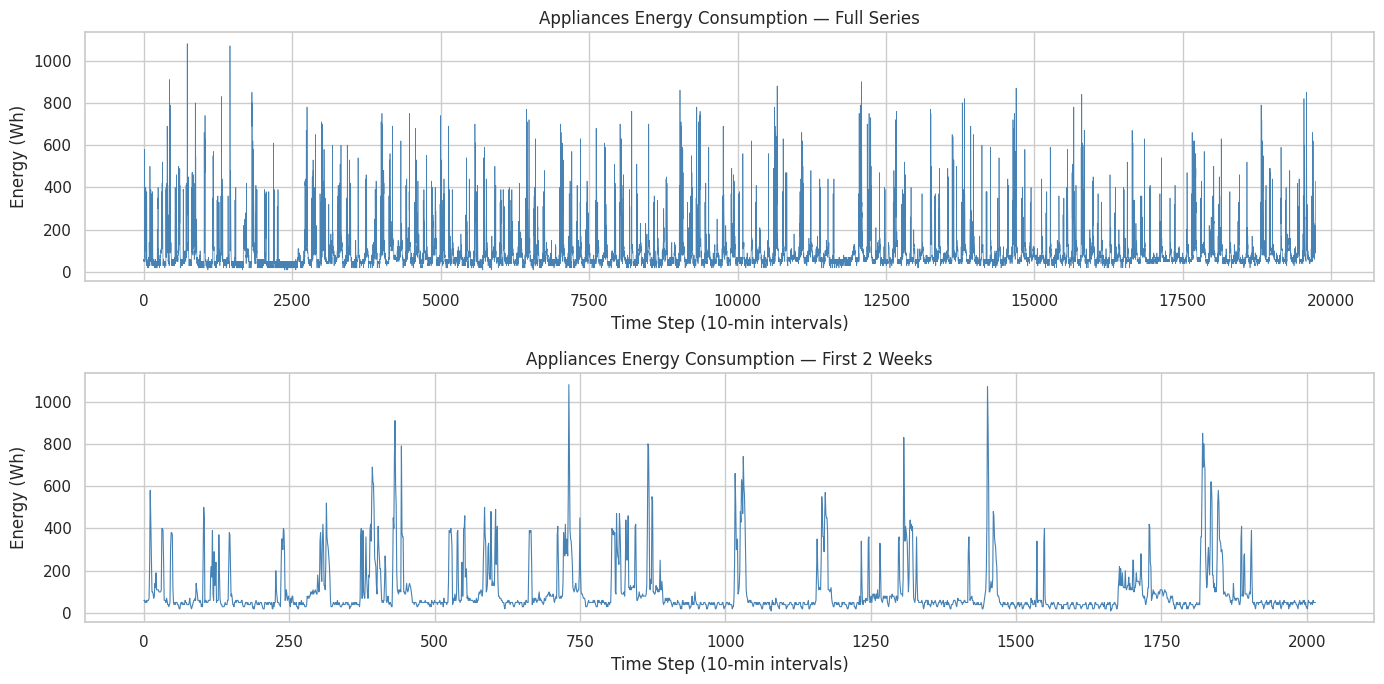

Total samples : 19,735
Min  : 10.0 Wh
Max  : 1080.0 Wh
Mean : 97.7 Wh
Std  : 102.5 Wh


In [47]:
# ANSWER
# Plot the raw y_energy series. Note trends, seasonality, and noise.

fig, axes = plt.subplots(2, 1, figsize=(14, 7))

# Full series
axes[0].plot(y_energy, linewidth=0.5, color="steelblue")
axes[0].set_title("Appliances Energy Consumption — Full Series")
axes[0].set_xlabel("Time Step (10-min intervals)")
axes[0].set_ylabel("Energy (Wh)")

# First 2016 steps (~2 weeks) for a closer look at short-term patterns
axes[1].plot(y_energy[:2016], linewidth=0.8, color="steelblue")
axes[1].set_title("Appliances Energy Consumption — First 2 Weeks")
axes[1].set_xlabel("Time Step (10-min intervals)")
axes[1].set_ylabel("Energy (Wh)")

plt.tight_layout()
plt.show()

print(f"Total samples : {len(y_energy):,}")
print(f"Min  : {y_energy.min():.1f} Wh")
print(f"Max  : {y_energy.max():.1f} Wh")
print(f"Mean : {y_energy.mean():.1f} Wh")
print(f"Std  : {y_energy.std():.1f} Wh")

### Reflective Exercise B1-A

**Q1:** From your plot, describe two qualitative properties of the appliances energy series that distinguish it from the synthetic sine wave in hw09. How might these properties make forecasting harder for a neural network?

**Answer:**
<br>
We can see that the appliances energy series is irregular and nonstationary. We can see that spikes in power usage happen randomly and the amplitude of these spikes also vary. This is different from something like a synthetic sine wave that is is quite regular (constant amplitude and period).
<br>

### Step B1.3: Temporal Split and Normalization

Apply the same temporal 80/10/10 split pattern from hw09. Fit `MinMaxScaler` on the training portion only.

In [48]:
show_todo("Perform temporal split and normalization on the energy series")

In [49]:
# ANSWER
# For univariate time series forecasting, we use just the target column (y_energy).
#   Perform an 80/10/10 temporal split.
n = len(y_energy)
train_end = int(n * 0.8)
val_end = int(n * 0.9)

train_raw = y_energy[:train_end].reshape(-1, 1)
val_raw = y_energy[train_end:val_end].reshape(-1, 1)
test_raw = y_energy[val_end:].reshape(-1, 1)

print(f"Train: {len(train_raw)} samples")
print(f"Val:   {len(val_raw)} samples")
print(f"Test:  {len(test_raw)} samples")

# DONE: Fit MinMaxScaler on train only, then transform all splits
scaler = MinMaxScaler()
train_scaled = scaler.fit_transform(train_raw)
val_scaled = scaler.transform(val_raw)
test_scaled = scaler.transform(test_raw)

print(f"\nTrain scaled range: [{train_scaled.min():.4f}, {train_scaled.max():.4f}]")
print(f"Val scaled range:   [{val_scaled.min():.4f}, {val_scaled.max():.4f}]")
print(f"Test scaled range:  [{test_scaled.min():.4f}, {test_scaled.max():.4f}]")

Train: 15788 samples
Val:   1973 samples
Test:  1974 samples

Train scaled range: [0.0000, 1.0000]
Val scaled range:   [0.0093, 0.7757]
Test scaled range:  [0.0093, 0.7850]


### Step B1.4: Create TimeSeriesDatasets and DataLoaders

In [50]:
show_todo("Create TimeSeriesDataset instances and DataLoaders")

In [51]:
# ANSWER
# DONE: Create TimeSeriesDataset for each split with SEQ_LEN=200, FORECAST_HORIZON=1
SEQ_LEN = 200
FORECAST_HORIZON = 1
BATCH_SIZE = 64

train_ts_ds = TimeSeriesDataset(train_scaled, seq_len=SEQ_LEN, forecast_horizon=FORECAST_HORIZON)
val_ts_ds = TimeSeriesDataset(val_scaled, seq_len=SEQ_LEN, forecast_horizon=FORECAST_HORIZON)
test_ts_ds = TimeSeriesDataset(test_scaled, seq_len=SEQ_LEN, forecast_horizon=FORECAST_HORIZON)

print(f"Train dataset: {len(train_ts_ds)} samples")
print(f"Val dataset:   {len(val_ts_ds)} samples")
print(f"Test dataset:  {len(test_ts_ds)} samples")

# DONE: Create DataLoaders
ts_train_loader, ts_val_loader, ts_test_loader = get_dataloaders(
    train_ts_ds, 
    val_ts_ds,
    test_ts_ds
)



# Verify shapes
x_batch, y_batch = next(iter(ts_train_loader))
print(f"\nBatch X shape: {x_batch.shape}")  # (batch, seq_len, 1)
print(f"Batch y shape: {y_batch.shape}")    # (batch, forecast_horizon)

Train dataset: 15588 samples
Val dataset:   1773 samples
Test dataset:  1774 samples

Batch X shape: torch.Size([64, 200, 1])
Batch y shape: torch.Size([64, 1])


### Step B1.5: Train a Vanilla RNN Baseline on Energy Data

In [52]:
show_todo("Train a vanilla RNN baseline on the energy time series")

In [53]:
# ANSWER
# DONE: Set epochs for time series
if RUN_TRAINING_MODE == RunTrainingMode.FULL:
    num_epochs_ts = 30
elif RUN_TRAINING_MODE == RunTrainingMode.QUICK:
    num_epochs_ts = 15
else:
    num_epochs_ts = 0

# DONE: Create ModelConfig for vanilla RNN time series model, with an rnn hidden size of 64. Classifier hidden units should be 32. 
# Don't forget the clip_grad_norm! Just use 1.0.
ts_rnn_config = ModelConfig(
    model_type=ModelType.RNN,
    embedding_dim=100,
    rnn_hidden_size=64,
    rnn_num_layers=1,
    rnn_type="rnn",
    hidden_units=[32],
    dropout=[0.3],
    clip_grad_norm=1.0,
)

ts_rnn_model = build_model(input_spec=1, num_outputs=FORECAST_HORIZON, config=ts_rnn_config)

print(ts_rnn_model)

# DONE: Create a TrainerConfig
ts_trainer_config = TrainerConfig(
    trainer_batch_size=BATCH_SIZE,
    evaluator_batch_size=256,
    learning_rate=1e-3,
    optimizer_name="adam",
    weight_decay=1e-5,
    device=accel_device,
    num_epochs=num_epochs_ts,
    early_stopping_patience=None,
)

# Train with MSELoss and regression metrics
with Trainer(
    model=ts_rnn_model,
    optimizer=make_optimizer(ts_rnn_model.parameters(), ts_trainer_config),
    criterion=nn.MSELoss(),
    config=ts_trainer_config,
    run=None,
    metrics_config=MetricsConfig(task="regression", names=["mae"]),
) as trainer:
    ts_rnn_results = trainer.fit(ts_train_loader, ts_val_loader)

print(f"\nVanilla RNN Time Series Results: {ts_rnn_results}")

RNNModel(type=rnn, uni, input=1, hidden=64, layers=1, out=1)
Epoch 0:
Train Mae=0.0398  Val Mae=0.0305
--> New best checkpoint saved: ./checkpoints/best.pt
--> Also saving as last checkpoint: ./checkpoints/last.pt
Epoch 1:
Train Mae=0.0327  Val Mae=0.0308
Epoch 2:
Train Mae=0.0322  Val Mae=0.0226
Epoch 3:
Train Mae=0.0317  Val Mae=0.0286
Epoch 4:
Train Mae=0.0325  Val Mae=0.0227
--> Saving checkpoint: ./checkpoints/last.pt
Epoch 5:
Train Mae=0.0314  Val Mae=0.0301
Epoch 6:
Train Mae=0.0317  Val Mae=0.0214
Epoch 7:
Train Mae=0.0320  Val Mae=0.0211
Epoch 8:
Train Mae=0.0317  Val Mae=0.0372
Epoch 9:
Train Mae=0.0317  Val Mae=0.0203
--> Saving checkpoint: ./checkpoints/last.pt
Epoch 10:
Train Mae=0.0315  Val Mae=0.0220
Epoch 11:
Train Mae=0.0315  Val Mae=0.0228
Epoch 12:
Train Mae=0.0315  Val Mae=0.0218
Epoch 13:
Train Mae=0.0314  Val Mae=0.0217
Epoch 14:
Train Mae=0.0315  Val Mae=0.0218
--> Saving checkpoint: ./checkpoints/last.pt
Epoch 15:
Train Mae=0.0312  Val Mae=0.0247
Epoch 16:
Train

### Reflective Exercise B1-B

**Q1:** Does your vanilla RNN's validation MAE decrease meaningfully during training, or does it plateau quickly? Based on the sequence length and the theory from the Background, what improvement — if any — do you expect from switching to an LSTM or GRU?

**Answer:**
<br>
No, it does not decrease meaningfully and plateaus quickly. This is probably due to the problem of vanishing gradients since the time steps are quite huge in this dataset. Switching to an LSTM or GRU should yield a meaningful improvement because both architectures use gated additive updates (the cell state highway in LSTM, and the interpolation in GRU) that allow gradients to flow across long distances without exponential decay
<br>

---
## Section B2: LSTM for Time Series Forecasting

Now train an LSTM on the same energy data and compare to the vanilla RNN baseline.

### Step B2.1: Configure and Train LSTM

In [54]:
show_todo("Train an LSTM on the energy time series")

In [55]:
# ANSWER
# DONE: Create ModelConfig with rnn_type="lstm", same architecture otherwise
ts_lstm_config = ModelConfig(
    model_type=ModelType.RNN,
    embedding_dim=100,
    rnn_hidden_size=64,
    rnn_num_layers=1,
    rnn_type="lstm",
    hidden_units=[32],
    dropout=[0.3],
    clip_grad_norm=1.0,
)

ts_lstm_model = build_model(input_spec=1, num_outputs=FORECAST_HORIZON, config=ts_lstm_config)
print(ts_lstm_model)

with Trainer(
    model=ts_lstm_model,
    optimizer=make_optimizer(ts_lstm_model.parameters(), ts_trainer_config),
    criterion=nn.MSELoss(),
    config=ts_trainer_config,
    run=None,
    metrics_config=MetricsConfig(task="regression", names=["mae"]),
) as trainer:
    ts_lstm_results = trainer.fit(ts_train_loader, ts_val_loader)

print(f"\nLSTM Time Series Results: {ts_lstm_results}")

RNNModel(type=lstm, uni, input=1, hidden=64, layers=1, out=1)
Epoch 0:
Train Mae=0.0578  Val Mae=0.0253
--> New best checkpoint saved: ./checkpoints/best.pt
--> Also saving as last checkpoint: ./checkpoints/last.pt
Epoch 1:
Train Mae=0.0390  Val Mae=0.0216
Epoch 2:
Train Mae=0.0332  Val Mae=0.0219
Epoch 3:
Train Mae=0.0306  Val Mae=0.0246
Epoch 4:
Train Mae=0.0303  Val Mae=0.0212
--> Saving checkpoint: ./checkpoints/last.pt
Epoch 5:
Train Mae=0.0312  Val Mae=0.0209
Epoch 6:
Train Mae=0.0308  Val Mae=0.0265
Epoch 7:
Train Mae=0.0306  Val Mae=0.0221
Epoch 8:
Train Mae=0.0307  Val Mae=0.0239
Epoch 9:
Train Mae=0.0313  Val Mae=0.0205
--> Saving checkpoint: ./checkpoints/last.pt
Epoch 10:
Train Mae=0.0311  Val Mae=0.0209
Epoch 11:
Train Mae=0.0309  Val Mae=0.0231
Epoch 12:
Train Mae=0.0305  Val Mae=0.0219
Epoch 13:
Train Mae=0.0316  Val Mae=0.0205
Epoch 14:
Train Mae=0.0308  Val Mae=0.0222
--> Saving checkpoint: ./checkpoints/last.pt
Epoch 15:
Train Mae=0.0310  Val Mae=0.0219
Epoch 16:
Trai

### Step B2.2: Evaluate on Test Set and Visualize

Now that the LSTM is trained, evaluate it on the held-out test set and visualize predictions against actual values. Follow these steps:

1. Set the model to evaluation mode (`model.eval()`) and move it to `accel_device`
2. Loop over `ts_test_loader` inside a `torch.no_grad()` context. For each batch:
   - Move `x_batch` to `accel_device`
   - Call `model(x_batch)`, squeeze the output, and move to CPU with `.cpu().numpy()`
   - Collect predictions and `y_batch` values into running lists
3. Concatenate the lists into NumPy arrays, then compute:
   - **Test MAE** = `np.mean(np.abs(preds - actuals))`
   - **Test RMSE** = `np.sqrt(np.mean((preds - actuals) ** 2))`
4. Create a line plot showing the first ~300 test samples with actual vs. predicted values on the same axes. Label axes and add a legend.

> **Note:** All values stay in *scaled* space (0–1 from MinMaxScaler). You do not need to inverse-transform for this step — relative error is what matters for comparison across models.

In [56]:
show_todo("Evaluate the LSTM on the test set and plot predictions vs. actuals")

RNN Test MAE (scaled):  0.064654
RNN Test RMSE (scaled): 0.111462


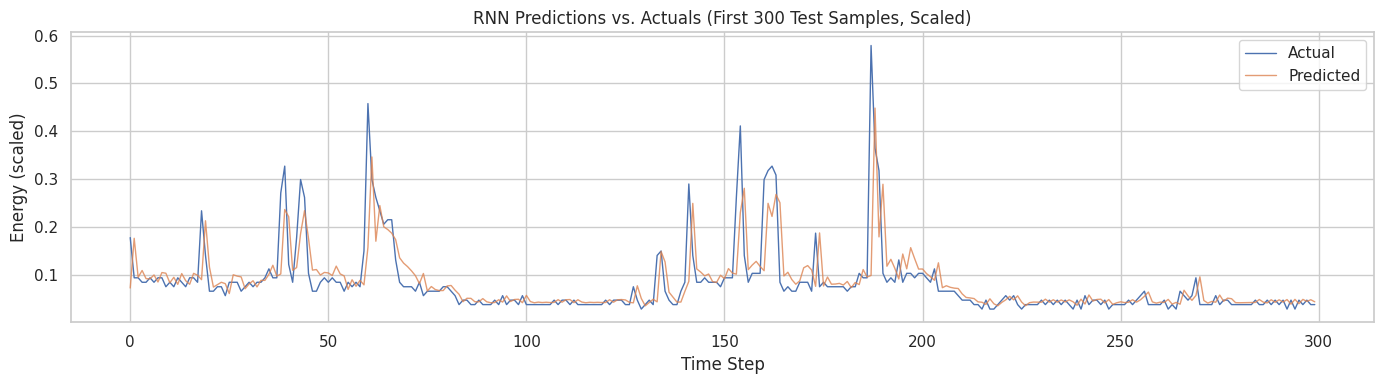

In [60]:
# ANSWER
# DONE: Run inference on the test set, collect predictions, and plot
ts_rnn_model.eval()
ts_rnn_model.to(accel_device)

all_preds = []
all_actuals = []

with torch.no_grad():
    for x_batch, y_batch in ts_test_loader:
        x_batch = x_batch.to(accel_device)
        pred = ts_rnn_model(x_batch).squeeze().cpu().numpy()
        all_preds.append(pred)
        all_actuals.append(y_batch)

preds = np.concatenate(all_preds)
actuals = np.concatenate(all_actuals)
# Compute test MAE and RMSE (in scaled space)
test_mae = np.mean(np.abs(preds - actuals))
test_rmse = np.sqrt(np.mean((preds - actuals) ** 2))
print(f"RNN Test MAE (scaled):  {test_mae:.6f}")
print(f"RNN Test RMSE (scaled): {test_rmse:.6f}")

# DONE: Plot the predicted vs. actual values. Add a title, label the axes and add a legend.
fig, ax = plt.subplots(figsize=(14, 4))
n_plot = 300                                                                                                                                                                                
ax.plot(actuals[:n_plot], label="Actual", linewidth=1.0)
ax.plot(preds[:n_plot], label="Predicted", linewidth=1.0, alpha=0.8)                                                                                                                          
ax.set_title("RNN Predictions vs. Actuals (First 300 Test Samples, Scaled)")
ax.set_xlabel("Time Step")                                                                                                                                                                    
ax.set_ylabel("Energy (scaled)")                                                                                                                                                            
ax.legend()  
plt.tight_layout()
plt.show()

LSTM Test MAE (scaled):  0.063040
LSTM Test RMSE (scaled): 0.111572


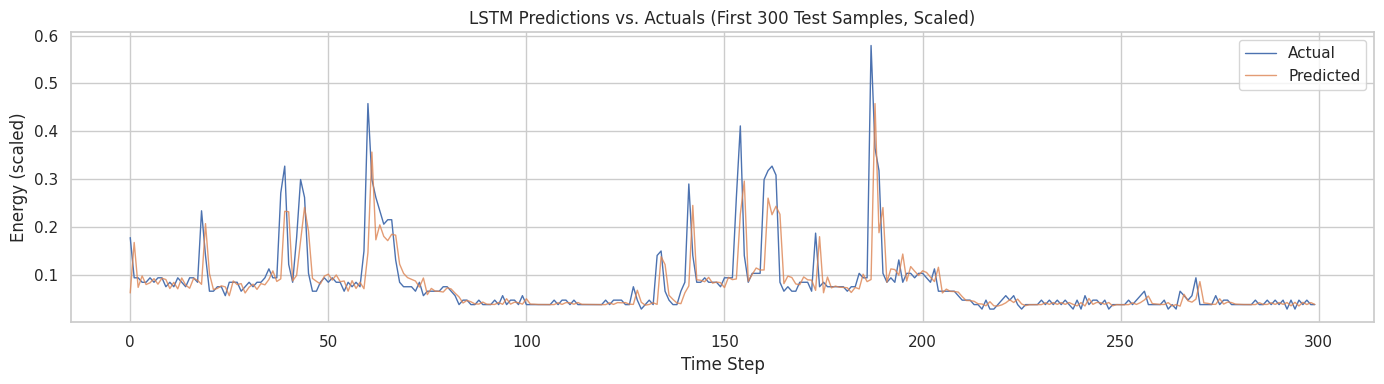

In [58]:
# ANSWER
# DONE: Run inference on the test set, collect predictions, and plot
ts_lstm_model.eval()
ts_lstm_model.to(accel_device)

all_preds = []
all_actuals = []

with torch.no_grad():
    for x_batch, y_batch in ts_test_loader:
        x_batch = x_batch.to(accel_device)
        pred = ts_lstm_model(x_batch).squeeze().cpu().numpy()
        all_preds.append(pred)
        all_actuals.append(y_batch)

preds = np.concatenate(all_preds)
actuals = np.concatenate(all_actuals)
# Compute test MAE and RMSE (in scaled space)
test_mae = np.mean(np.abs(preds - actuals))
test_rmse = np.sqrt(np.mean((preds - actuals) ** 2))
print(f"LSTM Test MAE (scaled):  {test_mae:.6f}")
print(f"LSTM Test RMSE (scaled): {test_rmse:.6f}")

# DONE: Plot the predicted vs. actual values. Add a title, label the axes and add a legend.
fig, ax = plt.subplots(figsize=(14, 4))
n_plot = 300                                                                                                                                                                                
ax.plot(actuals[:n_plot], label="Actual", linewidth=1.0)
ax.plot(preds[:n_plot], label="Predicted", linewidth=1.0, alpha=0.8)                                                                                                                          
ax.set_title("LSTM Predictions vs. Actuals (First 300 Test Samples, Scaled)")
ax.set_xlabel("Time Step")                                                                                                                                                                    
ax.set_ylabel("Energy (scaled)")                                                                                                                                                            
ax.legend()  
plt.tight_layout()
plt.show()

### Reflective Exercise B2

**Q1:** Compare the LSTM's test MAE (scaled space) to the vanilla RNN baseline from B1. Is the improvement meaningful? Looking at your prediction plot, describe where the LSTM succeeds and where it visibly fails.

**Answer:** 
<br>
The improvement is not that meaningful. The LSTM performs identical to the RNN. This is probably because the next 10 minute interval of power usage is almost entirely predicted by the last few time steps. The LSTM's advantage of having a cell state is not needed here.
<br>

**Q2:** Predictions are evaluated in scaled (0–1) space rather than the original Wh values. Why is it essential to fit the `MinMaxScaler` on the training split only, and not on the combined train+val+test data?

**Answer:**
<br>
This is because fitting the `MinMaxScaler` on the val and test data introduces information (data leakage) to the model during training. The model would implicitly know the scale of the future data, making training and evaluation unrealistically optimistic.
<br>

---
## Section B3: GRU for Time Series Forecasting

### Step B3.1: Train GRU

In [59]:
show_todo("Train a GRU on the energy time series")

In [61]:
# ANSWER
# DONE: Create ModelConfig with rnn_type="gru"
ts_gru_config = ModelConfig(
    model_type=ModelType.RNN,
    embedding_dim=100,
    rnn_hidden_size=64,
    rnn_num_layers=1,
    rnn_type="gru",
    hidden_units=[32],
    dropout=[0.3],
    clip_grad_norm=1.0,
)

ts_gru_model = build_model(input_spec=1, num_outputs=FORECAST_HORIZON, config=ts_gru_config)
print(ts_gru_model)

with Trainer(
    model=ts_gru_model,
    optimizer=make_optimizer(ts_gru_model.parameters(), ts_trainer_config),
    criterion=nn.MSELoss(),
    config=ts_trainer_config,
    run=None,
    metrics_config=MetricsConfig(task="regression", names=["mae"]),
) as trainer:
    ts_gru_results = trainer.fit(ts_train_loader, ts_val_loader)

print(f"\nGRU Time Series Results: {ts_gru_results}")

RNNModel(type=gru, uni, input=1, hidden=64, layers=1, out=1)
Epoch 0:
Train Mae=0.0421  Val Mae=0.0330
--> New best checkpoint saved: ./checkpoints/best.pt
--> Also saving as last checkpoint: ./checkpoints/last.pt
Epoch 1:
Train Mae=0.0338  Val Mae=0.0209
Epoch 2:
Train Mae=0.0328  Val Mae=0.0240
Epoch 3:
Train Mae=0.0322  Val Mae=0.0218
Epoch 4:
Train Mae=0.0322  Val Mae=0.0208
--> Saving checkpoint: ./checkpoints/last.pt
Epoch 5:
Train Mae=0.0320  Val Mae=0.0209
Epoch 6:
Train Mae=0.0321  Val Mae=0.0214
Epoch 7:
Train Mae=0.0325  Val Mae=0.0217
Epoch 8:
Train Mae=0.0317  Val Mae=0.0237
Epoch 9:
Train Mae=0.0318  Val Mae=0.0237
--> Saving checkpoint: ./checkpoints/last.pt
Epoch 10:
Train Mae=0.0318  Val Mae=0.0213
Epoch 11:
Train Mae=0.0315  Val Mae=0.0227
Epoch 12:
Train Mae=0.0317  Val Mae=0.0208
Epoch 13:
Train Mae=0.0316  Val Mae=0.0209
Epoch 14:
Train Mae=0.0317  Val Mae=0.0217
--> Saving checkpoint: ./checkpoints/last.pt
Epoch 15:
Train Mae=0.0314  Val Mae=0.0213
Epoch 16:
Train

### Step B3.2: Three-Way Time Series Comparison

In [59]:
show_todo("Build a 3-way comparison table for time series: RNN vs. LSTM vs. GRU")

In [62]:
# ANSWER
# Build a comparison DataFrame
ts_comparison = pd.DataFrame({
    "Architecture": ["Vanilla RNN", "LSTM", "GRU"],
    "Val MAE": [
        ts_rnn_results.get("val_mae", 0),
        ts_lstm_results.get("val_mae", 0),
        ts_gru_results.get("val_mae", 0),
    ],
    "Total Params": [
        sum(p.numel() for p in ts_rnn_model.parameters()),
        sum(p.numel() for p in ts_lstm_model.parameters()),
        sum(p.numel() for p in ts_gru_model.parameters()),
    ],
})

print(ts_comparison.to_string(index=False))

Architecture  Val MAE  Total Params
 Vanilla RNN 0.021474          6401
        LSTM 0.020446         19265
         GRU 0.021931         14977


### Reflective Exercise B3

**Q1:** On this dataset and sequence length (200), does the LSTM's extra complexity pay off compared to the GRU? Under what conditions might the difference be larger?

**Answer:**
<br>
No, the LSTM's complexity does not pay off here. The conditions where the LSTM shines is if there are long-range dependencies in the dataset. Here, energy usage in the next 10 minute interval probably does not depend on energy usage from a few hours ago.
<br>

In [ ]:
show_section("Challenges")

---
# Challenges

This week's challenges explore gated architectures from multiple angles: systematic sweeps, real-world financial data, regularization through depth and dropout, a preview of encoder-decoder models, and more challenging NLP datasets. You likely noticed that there were times that LSTM and GRU did not necessarily perform better than RNN. Why? Well, assuming your experiment was set up properly, it often comes down either a problem with your input data (e.g. not scaling), or you simply need to explore your hyperparameter spaces. **Several of your challenges will be about using W&B sweeps to find the best hyperparameters.**

## Challenge 1: RNN vs. LSTM vs. GRU — Systematic Comparison with W&B Sweep

In the Lab, you compared architectures with a single configuration. Now run a **systematic comparison** using a W&B sweep to see how all three recurrent architectures — vanilla RNN, LSTM, and GRU — perform across a range of hidden sizes and depths.

### Your task:

1. Define a W&B sweep config sweeping over:
   - `rnn_type ∈ {"rnn", "lstm", "gru"}` — include the vanilla RNN as a baseline!
   - `rnn_hidden_size ∈ {32, 64, 128}`
   - `rnn_num_layers ∈ {1, 2, 3}`
   - Use the IMDB dataset (classification, same setup as the Lab)
2. Run all **27 combinations** (3 types × 3 sizes × 3 layers) using `make_train_sweep`
3. **Analysis (required):** After the sweep completes:
   - Fetch results from W&B using the API and build a summary DataFrame
   - Create bar charts grouped by `rnn_type` showing accuracy for each configuration
   - Create a parameter efficiency plot: accuracy vs. total parameters, colored by architecture
   - Write a conclusion stating which architecture wins and under what conditions

**Success criteria:** A clear, data-driven recommendation — not cherry-picked results.

In [ ]:
# ANSWER
# Define the sweep config. Include all three rnn_type values so that the vanilla
#   RNN serves as a baseline against which LSTM and GRU improvements are measured.

num_epochs = 0
run_count = 0
if DO_WANDB_LOGGING:
    if RUN_TRAINING_MODE == RunTrainingMode.QUICK:
        num_epochs = 5
        run_count = 10
    elif RUN_TRAINING_MODE == RunTrainingMode.FULL:
        num_epochs = 20        
        run_count = 3*3*3*2

sweep_config_c1 = {
    "method": "grid",
    "metric": {"name": "val_accuracy", "goal": "maximize"},
    "parameters": {
        "model_type": {"value": "textrnn"},
        "rnn_type": {"values": ["rnn", "lstm", "gru"]},  # 3-way comparison
        "rnn_hidden_size": {"values": [32, 64, 128]},
        "rnn_num_layers": {"values": [1, 2, 3]},
        "rnn_bidirectional": {"value": False},
        "clip_grad_norm": {"values": [0, 1.0]},
        "vocab_size": {"value": len(imdb_vocab)},
        "embedding_dim": {"value": 100},
        "padding_idx": {"value": 0},
        "freeze_embeddings": {"value": False},
        "hidden_units": {"value": [64]},
        "dropout": {"value": [0.2]},
        "learning_rate": {"value": 5e-4},
        "weight_decay": {"value": 1e-5},
        "num_epochs": {"value": num_epochs},
        "trainer_batch_size": {"value": 64},
        "evaluator_batch_size": {"value": 256},
        "loss_name": {"value": "cross_entropy"},
    },
}

In [82]:
# ANSWER
# DONE: Create the sweep training function using make_train_sweep. This wraps the
#   engine's training pipeline so wandb.agent can call it for each run configuration.
train_fn_c1 = make_train_sweep(
    wandb_project_name="csci357-hw10-text",
    wandb_entity_name=entity,
    wandb_name_prefix=user_initials,
    metrics_config_param=MetricsConfig(task="multiclass", names=["accuracy", "loss"]),
    datasets=(imdb_train_ds, imdb_test_ds),
    device=accel_device,
    input_spec=1,
    num_outputs=2,
    text_collate_fn=text_collate_fn
)

In [83]:
# ANSWER
# DONE: Register the sweep with W&B and launch the agent with the specified number of runs.

if DO_WANDB_LOGGING and RUN_TRAINING_MODE != RunTrainingMode.NONE:
    sweep_id_c1 = wandb.sweep(sweep_config_c1, project="csci357-hw10-text", entity=entity)
    wandb.agent(sweep_id_c1, function=train_fn_c1, count=run_count)
else:
    sweep_id_c1 = None



Create sweep with ID: hw773qcz
Sweep URL: https://wandb.ai/bucknell-university-csci357-2026sp/csci357-hw10-text/sweeps/hw773qcz


wandb: Agent Starting Run: b4lpr9tn with config:
wandb: 	clip_grad_norm: 0
wandb: 	dropout: [0.2]
wandb: 	embedding_dim: 100
wandb: 	evaluator_batch_size: 256
wandb: 	freeze_embeddings: False
wandb: 	hidden_units: [64]
wandb: 	learning_rate: 0.0005
wandb: 	loss_name: cross_entropy
wandb: 	model_type: textrnn
wandb: 	num_epochs: 20
wandb: 	padding_idx: 0
wandb: 	rnn_bidirectional: False
wandb: 	rnn_hidden_size: 32
wandb: 	rnn_num_layers: 1
wandb: 	rnn_type: rnn
wandb: 	trainer_batch_size: 64
wandb: 	vocab_size: 25002
wandb: 	weight_decay: 1e-05
wandb: [wandb.login()] Loaded credentials for https://api.wandb.ai from /root/.netrc.


wandb.config: {'clip_grad_norm': 0, 'dropout': [0.2], 'embedding_dim': 100, 'evaluator_batch_size': 256, 'freeze_embeddings': False, 'hidden_units': [64], 'learning_rate': 0.0005, 'loss_name': 'cross_entropy', 'model_type': 'textrnn', 'num_epochs': 20, 'padding_idx': 0, 'rnn_bidirectional': False, 'rnn_hidden_size': 32, 'rnn_num_layers': 1, 'rnn_type': 'rnn', 'trainer_batch_size': 64, 'vocab_size': 25002, 'weight_decay': 1e-05}
Run name set to: CMB_textrnn_bs64_lr0.00050_hs32_L1_bi0_rnn_wd0.00001
Epoch 0:
Train Accuracy=52.75%  Val Accuracy=55.02%
Train Loss=0.6902  Val Loss=0.6825
--> New best checkpoint saved: ./checkpoints/csci357-hw10-text-best.pt
--> Also saving as last checkpoint: ./checkpoints/csci357-hw10-text-last.pt
Epoch 1:
Train Accuracy=58.01%  Val Accuracy=56.81%
Train Loss=0.6712  Val Loss=0.6715
--> New best checkpoint saved: ./checkpoints/csci357-hw10-text-best.pt
--> Also saving as last checkpoint: ./checkpoints/csci357-hw10-text-last.pt
Epoch 2:
Train Accuracy=60.37%

epoch,▁▂▂▃▃▄▄▅▅▆▆▇▇█
train_accuracy,▁▂▂▃▃▄▅▆▆▇▇▇██
train_loss,██▇▇▇▆▆▅▄▃▃▂▁▁
val_accuracy,▁▂▂▃▃▅▆▇▇▇▇███
val_loss,▅▄▄▄▃▂▁▁▁▂▃▄▆█
epoch,13
train_accuracy,0.93871
train_loss,0.16555
val_accuracy,0.73269
val_loss,0.75195


Run complete! val_loss: 0.7520 val_accuracy: 73.27%


...

Run complete! val_loss: 0.7061 val_accuracy: 81.65%


wandb: Agent Starting Run: ri9vwz0l with config:
wandb: 	clip_grad_norm: 1
wandb: 	dropout: [0.2]
wandb: 	embedding_dim: 100
wandb: 	evaluator_batch_size: 256
wandb: 	freeze_embeddings: False
wandb: 	hidden_units: [64]
wandb: 	learning_rate: 0.0005
wandb: 	loss_name: cross_entropy
wandb: 	model_type: textrnn
wandb: 	num_epochs: 20
wandb: 	padding_idx: 0
wandb: 	rnn_bidirectional: False
wandb: 	rnn_hidden_size: 128
wandb: 	rnn_num_layers: 3
wandb: 	rnn_type: gru
wandb: 	trainer_batch_size: 64
wandb: 	vocab_size: 25002
wandb: 	weight_decay: 1e-05
wandb: [wandb.login()] Loaded credentials for https://api.wandb.ai from /root/.netrc.


wandb.config: {'clip_grad_norm': 1, 'dropout': [0.2], 'embedding_dim': 100, 'evaluator_batch_size': 256, 'freeze_embeddings': False, 'hidden_units': [64], 'learning_rate': 0.0005, 'loss_name': 'cross_entropy', 'model_type': 'textrnn', 'num_epochs': 20, 'padding_idx': 0, 'rnn_bidirectional': False, 'rnn_hidden_size': 128, 'rnn_num_layers': 3, 'rnn_type': 'gru', 'trainer_batch_size': 64, 'vocab_size': 25002, 'weight_decay': 1e-05}
Run name set to: CMB_textrnn_bs64_lr0.00050_hs128_L3_bi0_gru_wd0.00001
Epoch 0:
Train Accuracy=58.08%  Val Accuracy=65.66%
Train Loss=0.6694  Val Loss=0.6358
--> New best checkpoint saved: ./checkpoints/csci357-hw10-text-best.pt
--> Also saving as last checkpoint: ./checkpoints/csci357-hw10-text-last.pt
Epoch 1:
Train Accuracy=68.95%  Val Accuracy=66.29%
Train Loss=0.5940  Val Loss=0.6285
--> New best checkpoint saved: ./checkpoints/csci357-hw10-text-best.pt
--> Also saving as last checkpoint: ./checkpoints/csci357-hw10-text-last.pt
Epoch 2:
Train Accuracy=75.4

epoch,▁▂▃▃▄▅▆▆▇█
train_accuracy,▁▃▄▅▆▇▇███
train_loss,█▇▆▅▄▃▂▂▁▁
val_accuracy,▁▁▅▇█▇████
val_loss,██▄▃▁▂▂▂▃▄
epoch,9
train_accuracy,0.96024
train_loss,0.11198
val_accuracy,0.83688
val_loss,0.48813


Run complete! val_loss: 0.4881 val_accuracy: 83.69%


### Challenge 1 Analysis

After the sweep completes, use the W&B API to fetch the results and build visualizations.

**1. Data from the sweep (integrity)**  
- Use the W&B API to pull **every run** in *this* sweep (filter by sweep ID), not a hand-picked subset.  
- Build a table with at least: `rnn_type`, `rnn_hidden_size`, `rnn_num_layers`, **best / final `val_accuracy`**, and **total parameters** (rebuild `ModelConfig` + `build_model` and use `num_parameters()` if counts were not logged).  
- Report how many runs you expected  vs. how many rows you got; briefly note any failed or missing runs.

**2. Performance comparison (not one number)**  
- For each architecture, report **best** validation accuracy **and** **mean** (and optionally std/min) across all configs—so the story is not “I found one good LSTM run.”  

**3. Required visualizations (tie each to a question)**  
- **Grouped bar chart:** accuracy vs. configuration (e.g. `hs` × `layers`), **grouped by `rnn_type`**. Question answered: *Which architecture is consistently better across the grid?*  
- **Parameter efficiency:** scatter of **validation accuracy vs. total parameters**, **colored by architecture**. Question answered: *Who gets the best accuracy for a given model size?*  
- **Efficiency metric (optional but strong):** e.g. accuracy per million parameters (or similar)—**aggregated by architecture** (mean with error bars or clear statement). Question answered: *If deployment cost is “parameters,” what’s the tradeoff?*

**4. Interpretation (conditions, not slogans)**  
- Comment on **interactions**: e.g. does the gap between vanilla RNN vs. gated models **grow with depth** or **hidden size**?  
- Relate observations to **mechanism** in one short paragraph (vanishing gradients / long-term dependencies vs. gating)—only where the **numbers** support it.  

**5. “No cherry-picking” (explicit success criterion)**  
- Recommendation must be justified by your sweep results, not just commenting on a single run.  
- **Written conclusion** in a few sentences: which architecture you’d recommend **by default**, when you’d switch (e.g. very deep / very long sequences), and what you’d try next if results were flat (within scope of the assignment).


In [111]:
# ANSWER
# DONE: Use wandb.Api() to fetch all runs from the sweep and assemble a results DataFrame.
#   For each run, extract: rnn_type, hidden_size, num_layers, val_accuracy, and parameter count.
#   Rebuild each model from its config to get an exact parameter count.
if sweep_id_c1 is None:
    raise RuntimeError(
        "Sweep has not been run. Set DO_WANDB_LOGGING=True and RUN_TRAINING_MODE != NONE, "
        "then re-run the sweep cell above before executing this analysis."
    )

api = wandb.Api(timeout=60)
api.flush()
sweep_runs = api.runs(
    f"{entity}/csci357-hw10-text",
    filters={"sweep": sweep_id_c1},
)

print(f"# sweep_runs: {len(sweep_runs)}")

print(sweep_runs[0])
print(sweep_runs[0].config)
print(sweep_runs[0].summary)
import json
cfg = json.loads(sweep_runs[0].json_config)
print("Keys in cfg:", cfg.keys())
print("rnn_type:", cfg["rnn_type"]["value"])

# sweep_runs: 54
<Run bucknell-university-csci357-2026sp/csci357-hw10-text/b4lpr9tn (finished)>
{}
{'_runtime': 19.981914776, '_step': 13, '_timestamp': 1775149923.1509902, '_wandb': {'runtime': 19}, 'epoch': 13, 'gradients/graph_22classifier_head.0.bias': {'_type': 'histogram'}, 'gradients/graph_22classifier_head.0.weight': {'_type': 'histogram'}, 'gradients/graph_22classifier_head.3.bias': {'_type': 'histogram'}, 'gradients/graph_22classifier_head.3.weight': {'_type': 'histogram'}, 'gradients/graph_22embedding.weight': {'_type': 'histogram'}, 'gradients/graph_22rnn.bias_hh_l0': {'_type': 'histogram'}, 'gradients/graph_22rnn.bias_ih_l0': {'_type': 'histogram'}, 'gradients/graph_22rnn.weight_hh_l0': {'_type': 'histogram'}, 'gradients/graph_22rnn.weight_ih_l0': {'_type': 'histogram'}, 'parameters/graph_22classifier_head.0.bias': {'_type': 'histogram'}, 'parameters/graph_22classifier_head.0.weight': {'_type': 'histogram'}, 'parameters/graph_22classifier_head.3.bias': {'_type': 'histogram

In [114]:

records = []
for run in sweep_runs:
    # if not run.config:
    #     print("cfg is None or empty")
    #     continue
    print(run.summary)
    print(f"rnn_type: {run.config.get('rnn_type', "?")}")
    
    summary = run.summary

    rnn_type = run.config.get("rnn_type", "?")                                                                                                                                          
    hidden_size = run.config.get("rnn_hidden_size", "?")
    num_layers = run.config.get("rnn_num_layers", "?")
    val_acc = summary.get("val_accuracy", float("nan"))

    # Rebuild the model from its config to get an exact parameter count.
    # This avoids having to log parameter counts during the sweep itself.
    m_cfg = ModelConfig(
        model_type=ModelType.TEXTRNN,
        vocab_size=len(imdb_vocab),
        embedding_dim=100,
        padding_idx=0,
        rnn_hidden_size=hidden_size,
        rnn_num_layers=num_layers,
        rnn_type=rnn_type,
        bidirectional=False,
        hidden_units=[64],
        dropout=[0.3],
    )
    m = build_model(input_spec=1, num_outputs=2, config=m_cfg)
    total_params, _ = m.num_parameters()

    records.append({
        "rnn_type": rnn_type,
        "hidden_size": hidden_size,
        "num_layers": num_layers,
        "val_accuracy": val_acc,
        "total_params": total_params,
        "params_M": total_params / 1e6,
        # Accuracy per million parameters — a measure of parameter efficiency
        "acc_per_param_M": val_acc / (total_params / 1e6) if total_params > 0 else 0,
    })

c1_df = pd.DataFrame(records).sort_values("val_accuracy", ascending=False)
print(c1_df.to_string(index=False))

{'_runtime': 19.981914776, '_step': 13, '_timestamp': 1775149923.1509902, '_wandb': {'runtime': 19}, 'epoch': 13, 'gradients/graph_22classifier_head.0.bias': {'_type': 'histogram'}, 'gradients/graph_22classifier_head.0.weight': {'_type': 'histogram'}, 'gradients/graph_22classifier_head.3.bias': {'_type': 'histogram'}, 'gradients/graph_22classifier_head.3.weight': {'_type': 'histogram'}, 'gradients/graph_22embedding.weight': {'_type': 'histogram'}, 'gradients/graph_22rnn.bias_hh_l0': {'_type': 'histogram'}, 'gradients/graph_22rnn.bias_ih_l0': {'_type': 'histogram'}, 'gradients/graph_22rnn.weight_hh_l0': {'_type': 'histogram'}, 'gradients/graph_22rnn.weight_ih_l0': {'_type': 'histogram'}, 'parameters/graph_22classifier_head.0.bias': {'_type': 'histogram'}, 'parameters/graph_22classifier_head.0.weight': {'_type': 'histogram'}, 'parameters/graph_22classifier_head.3.bias': {'_type': 'histogram'}, 'parameters/graph_22classifier_head.3.weight': {'_type': 'histogram'}, 'parameters/graph_22embe

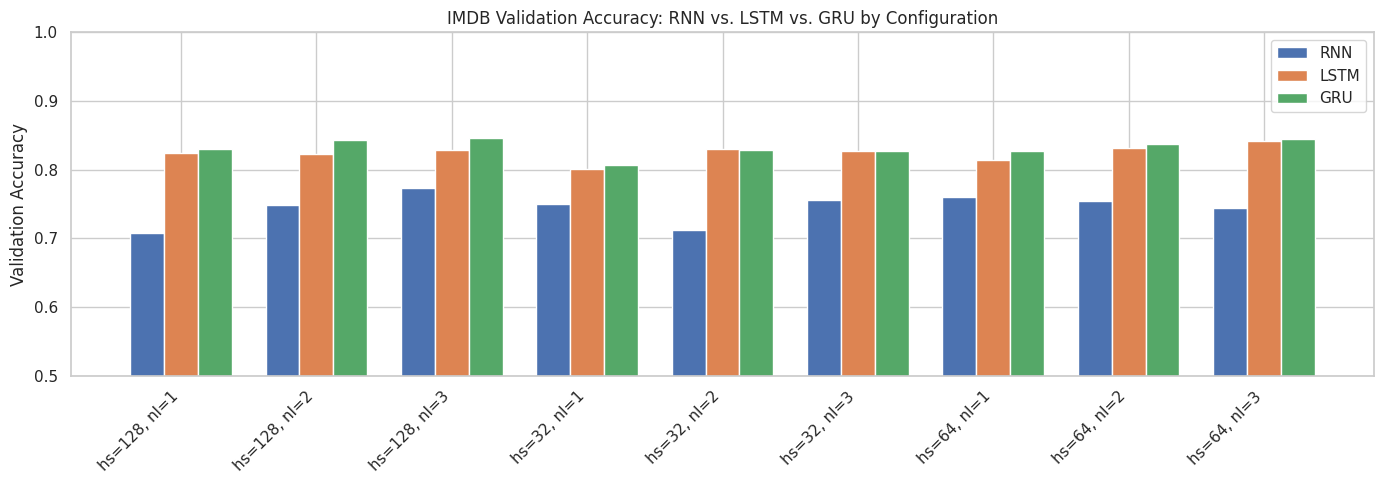

In [ ]:
# ANSWER
# DONE: Create a grouped bar chart comparing val_accuracy across all configurations,
#   with bars grouped by rnn_type (rnn, lstm, gru) and x-axis labeled by config.
arch_order = ["rnn", "lstm", "gru"]
colors = {"rnn": "#4c72b0", "lstm": "#dd8452", "gru": "#55a868"}
bar_width = 0.25

c1_df["config_label"] = c1_df.apply(
    lambda r: f"hs={int(r['hidden_size'])}, nl={int(r['num_layers'])}", axis=1
)
config_labels = sorted(c1_df["config_label"].unique())
x = np.arange(len(config_labels))

fig, ax = plt.subplots(figsize=(14, 5))
for i, arch in enumerate(arch_order):
    subset = (
        c1_df[c1_df["rnn_type"] == arch]
        .groupby("config_label")["val_accuracy"]
        .max()
    )
    vals = [subset.loc[label] if label in subset.index else 0 for label in config_labels]
    ax.bar(x + i * bar_width, vals, bar_width, label=arch.upper(), color=colors[arch])
ax.set_xticks(x + bar_width)
ax.set_xticklabels(config_labels, rotation=45, ha="right")
ax.set_ylabel("Validation Accuracy")
ax.set_title("IMDB Validation Accuracy: RNN vs. LSTM vs. GRU by Configuration")
ax.legend()
ax.set_ylim(0.5, 1.0)
plt.tight_layout()
plt.show()

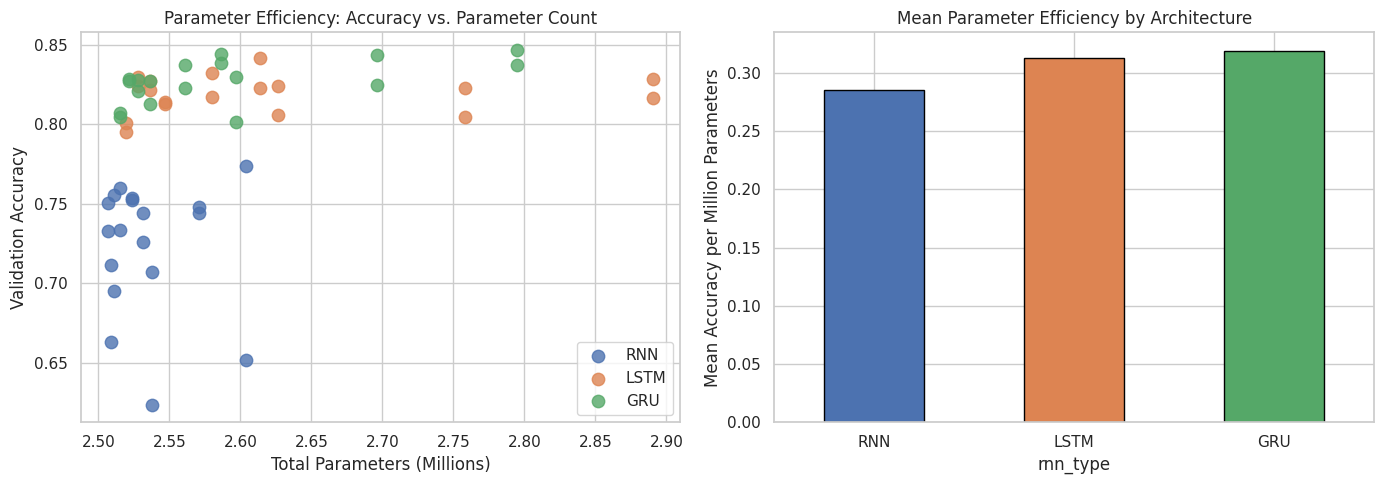

In [118]:
# ANSWER
# DONE: Create two parameter efficiency visualizations:
#   1. A scatter plot of accuracy vs. total parameters, colored by architecture
#   2. A bar chart of mean accuracy-per-million-parameters by architecture

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Scatter: accuracy vs. parameter count
for arch in arch_order:
    subset = c1_df[c1_df["rnn_type"] == arch]
    axes[0].scatter(
        subset["params_M"], subset["val_accuracy"],
        label=arch.upper(), color=colors[arch], s=80, alpha=0.8,
    )
axes[0].set_xlabel("Total Parameters (Millions)")
axes[0].set_ylabel("Validation Accuracy")
axes[0].set_title("Parameter Efficiency: Accuracy vs. Parameter Count")
axes[0].legend()

# Bar: mean accuracy-per-million-parameters by architecture
eff_df = c1_df.groupby("rnn_type")["acc_per_param_M"].mean().reindex(arch_order)
eff_df.plot(
    kind="bar", ax=axes[1],
    color=[colors[a] for a in arch_order], edgecolor="black",
)
axes[1].set_xticklabels([a.upper() for a in arch_order], rotation=0)
axes[1].set_ylabel("Mean Accuracy per Million Parameters")
axes[1].set_title("Mean Parameter Efficiency by Architecture")

plt.tight_layout()
plt.show()

### Challenge 1 Written Conclusion

**Answer:**

<br>
Here, we can see that the GRU performs better than the LSTM with fewer parameters. THe RNN is also not too bad in terms of accuracy, but the GRU may be the most cost-efficient way of getting the best performance in this case.
<br>


**Practical recommendation:** 

<br>
My recommendation would be to use GRUs (2-3 layers) with a hidden size of 32 or 64.
<br>

## Challenge 2: NVDA Stock Forecasting Competition (5-Day Horizon)

This is a **class competition**. Everyone forecasts the same stock (NVDA) over the same 5-day horizon, using the same pipeline structure. Your aim is to acheive the **lowest 5-day MAE on the test set**.

NVIDIA (NVDA) is one of the most consequential companies in the AI revolution — powering the GPUs that train the very models we study in this course. Its stock price reflects the market's belief in AI's future. Can your LSTM or GRU predict where it's headed?

### Your task:

1. Download NVDA daily closing prices from 2020-01-01 to 2025-01-01 using `yfinance`. You'll need to convert the data to daily percent change (directions given)
2. Apply the full time series pipeline: temporal split, `MinMaxScaler`, `TimeSeriesDataset` with `FORECAST_HORIZON=5`
3. Run a W&B grid sweep over:
   - `rnn_type ∈ {"lstm", "gru"}`
   - `rnn_hidden_size ∈ {32, 64, 128}`
   - `rnn_num_layers ∈ {1, 2}`
   - `learning_rate ∈ {1e-3, 5e-4}`
4. Report the best configuration and its **5-day MAE** on the test set
5. Compare to a naive persistence baseline (predict all 5 days to be the average daily change from the training data)
6. Visualize predictions on the test set showing all 5 forecast days (you can do this in 5 different charts)
7. **Reflect honestly:** Would this model be useful for actual trading decisions? What more is needed here?


[*********************100%***********************]  1 of 1 completed


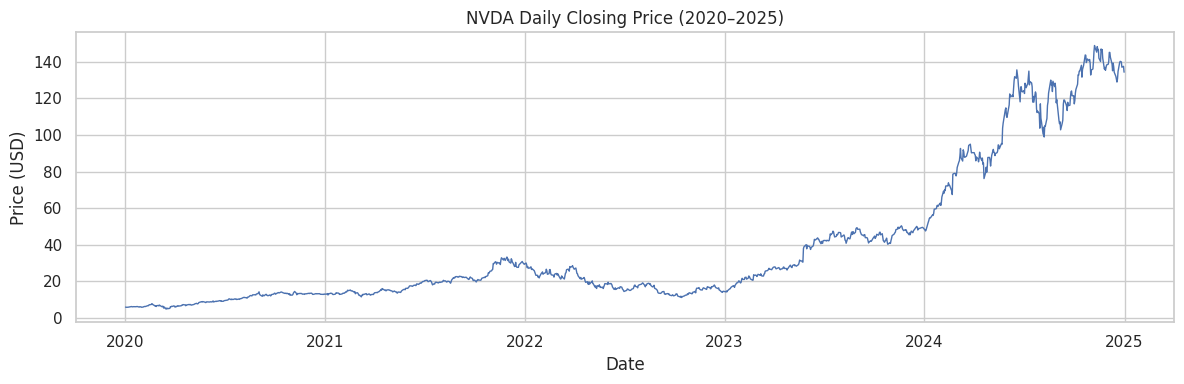

In [119]:
# ANSWER
import yfinance as yf

# DONE: Download NVDA daily closing prices from 2020-01-01 to 2025-01-01 using `yfinance`
nvda = yf.download("NVDA", start="2020-01-01", end="2025-01-01", auto_adjust=True)
nvda_close = nvda["Close"].squeeze().dropna()

# DONE: Plot daily closing prices
fig, ax = plt.subplots(figsize=(12, 4))
ax.plot(nvda_close.index, nvda_close.values, linewidth=1.0)
ax.set_title("NVDA Daily Closing Price (2020–2025)")
ax.set_xlabel("Date")
ax.set_ylabel("Price (USD)")
plt.tight_layout()
plt.show()

### A Note on Forecasting Stock Prices vs. Returns

**Why predict returns instead of raw prices?**

Most naive stock forecasting models try to predict the actual price (e.g., "NVDA will be $170.50 tomorrow"). This approach has several problems:

1. **Non-stationarity**: Stock prices exhibit trends and drift over time. A model trained on 2020 prices ($50–100) will struggle when prices reach $500+ in 2024.
2. **Scale sensitivity**: Neural networks trained on raw prices learn to predict "around $500" rather than learning the *dynamics* of price movement.
3. **Misleading accuracy**: Predicting "$500" when the true price is "$505" looks good (1% error), but tells you nothing about whether to buy or sell.

**A better approach: predict daily returns (fractional changes (or percent if multiplied by 100))**

Professional quants typically forecast **returns** instead:

$$r_t = \frac{P_t - P_{t-1}}{P_{t-1}} = \frac{\Delta P_t}{P_{t-1}}$$

This transformation:
- Makes the series more **stationary** (mean-reverting around 0%)
- Captures the **dynamics** of price movement rather than absolute levels
- Is **scale-invariant**: a 2% gain means the same thing whether the stock is $50 or $500
- Aligns with how traders think: "Will it go up or down, and by how much?"

In a real trading system, you would:
1. Convert prices to returns: 
2. Train your model on returns
3. Convert predictions back to prices for evaluation

This is a key lesson: **the representation you choose to model matters as much as the architecture itself.**

Series length    : 1,257
Mean daily return: 0.00268
Std daily return : 0.02812
Return range     : [-0.05093, 0.05538]


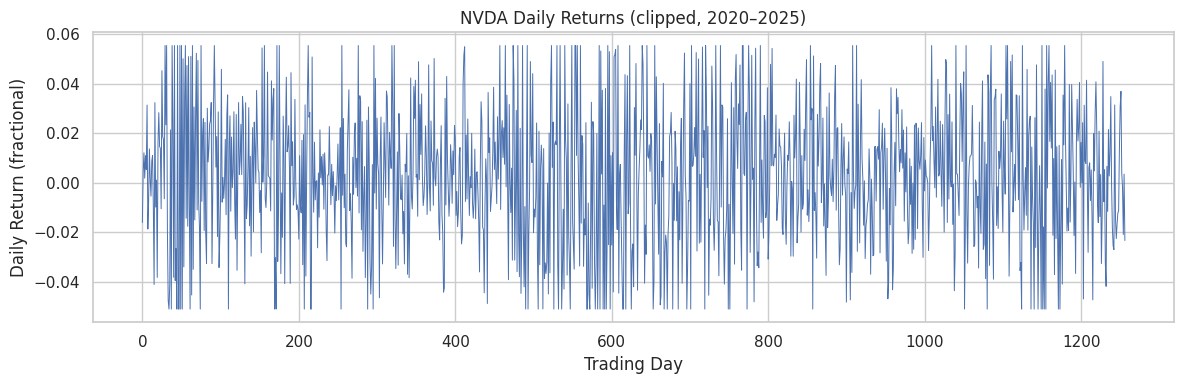

In [120]:
# ANSWER
# DONE: Create a returns-based dataset (fractional change from day to day)
# Convert prices to daily returns: r_t = (P_t - P_{t-1}) / P_{t-1}

nvda_returns = nvda_close.pct_change().dropna().values.astype(np.float32)

# DONE: Clip returns to fall between the 5th and 95th percentiles to avoid extreme outliers
p5, p95 = np.percentile(nvda_returns, 5), np.percentile(nvda_returns, 95)
nvda_returns = np.clip(nvda_returns, p5, p95)


# DONE: Print series length, mean daily return, std daily return, and return range

print(f"Series length    : {len(nvda_returns):,}")
print(f"Mean daily return: {nvda_returns.mean():.5f}")
print(f"Std daily return : {nvda_returns.std():.5f}")
print(f"Return range     : [{nvda_returns.min():.5f}, {nvda_returns.max():.5f}]")



# DONE: Plot daily returns
fig, ax = plt.subplots(figsize=(12, 4))
ax.plot(nvda_returns, linewidth=0.7)
ax.set_title("NVDA Daily Returns (clipped, 2020–2025)")
ax.set_xlabel("Trading Day")
ax.set_ylabel("Daily Return (fractional)")
plt.tight_layout()
plt.show()

You can load your own sweep (do not use the class entity parameter) to try to acheive the best results you can. 

In [121]:
# ANSWER
# DONE: Temporal split, normalization, TimeSeriesDataset with FORECAST_HORIZON=5
# Remember, use 80%/10%/10% split for train/val/test
# AIM: Predict the next 5 days of daily returns

STOCK_SEQ_LEN = 30
STOCK_HORIZON = 5

n = len(nvda_returns)
train_end = int(n * 0.8)
val_end = int(n * 0.9)


stock_train_raw = nvda_returns[:train_end]
stock_val_raw = nvda_returns[train_end:val_end]
stock_test_raw = nvda_returns[val_end:]

print(f"Train: {len(stock_train_raw)} | Val: {len(stock_val_raw)} | Test: {len(stock_test_raw)}")

stock_scaler = MinMaxScaler()
stock_train_scaled = stock_scaler.fit_transform(stock_train_raw.reshape(-1, 1))
stock_val_scaled = stock_scaler.transform(stock_val_raw.reshape(-1, 1))
stock_test_scaled = stock_scaler.transform(stock_test_raw.reshape(-1, 1))

stock_train_ds = TimeSeriesDataset(stock_train_scaled, seq_len=STOCK_SEQ_LEN, forecast_horizon=STOCK_HORIZON)
stock_val_ds = TimeSeriesDataset(stock_val_scaled, seq_len=STOCK_SEQ_LEN, forecast_horizon=STOCK_HORIZON)
stock_test_ds = TimeSeriesDataset(stock_test_scaled, seq_len=STOCK_SEQ_LEN, forecast_horizon=STOCK_HORIZON)

stock_train_loader, stock_val_loader, stock_test_loader = get_dataloaders(
    stock_train_ds, stock_val_ds, stock_test_ds
)

x_b, y_b = next(iter(stock_train_loader))
print(f"Batch X shape: {x_b.shape}")  # (batch, seq_len, 1)
print(f"Batch y shape: {y_b.shape}")  # (batch, 5)

Train: 1005 | Val: 126 | Test: 126
Batch X shape: torch.Size([64, 30, 1])
Batch y shape: torch.Size([64, 5])


In [122]:
num_epochs = 10
sweep_count = 10
if DO_WANDB_LOGGING:
    if RUN_TRAINING_MODE == RunTrainingMode.FULL:
        num_epochs = 20
        sweep_count = 2*3*2*2 # rnn_type × hidden_size × num_layers × lr
else:
    num_epochs = 1
    sweep_count = 1

# DONE: Define the sweep config for the stock competition
sweep_config_stock = {
    "method": "grid",
    "metric": {"name": "val_loss", "goal": "minimize"},
    "parameters": {
        "model_type":       {"value": "rnn"},
        "rnn_type":         {"values": ["lstm", "gru"]},
        "rnn_hidden_size":  {"values": [32, 64, 128]},
        "rnn_num_layers":   {"values": [1, 2]},
        "rnn_bidirectional":{"value": False},
        "clip_grad_norm":   {"value": 1.0},
        "hidden_units":     {"value": [32]},
        "dropout":          {"value": [0.2]},
        "learning_rate":    {"values": [1e-3, 5e-4]},
        "weight_decay":     {"value": 1e-5},
        "num_epochs":       {"value": num_epochs},
        "trainer_batch_size":    {"value": 32},
        "evaluator_batch_size":  {"value": 128},
        "loss_name":        {"value": "mse"},
    },
}



stock_train_fn = make_train_sweep(
    wandb_project_name="csci357-hw10-chal02-nvda",
    wandb_entity_name=entity,
    wandb_name_prefix=user_initials,
    metrics_config_param=MetricsConfig(task="regression", names=["mae"]),
    datasets=(stock_train_ds, stock_val_ds),
    device=accel_device,
    input_spec=1,
    num_outputs=STOCK_HORIZON
)

# Train the model
if DO_WANDB_LOGGING and RUN_TRAINING_MODE != RunTrainingMode.NONE:
    sweep_id_stock = wandb.sweep(sweep_config_stock, project="csci357-hw10-chal02-nvda", entity=entity)
    wandb.agent(sweep_id_stock, function=stock_train_fn, count=sweep_count)
else:
    sweep_id_stock = None




Create sweep with ID: sb7b41js
Sweep URL: https://wandb.ai/bucknell-university-csci357-2026sp/csci357-hw10-chal02-nvda/sweeps/sb7b41js


wandb: Agent Starting Run: obwoayqs with config:
wandb: 	clip_grad_norm: 1
wandb: 	dropout: [0.2]
wandb: 	evaluator_batch_size: 128
wandb: 	hidden_units: [32]
wandb: 	learning_rate: 0.001
wandb: 	loss_name: mse
wandb: 	model_type: rnn
wandb: 	num_epochs: 20
wandb: 	rnn_bidirectional: False
wandb: 	rnn_hidden_size: 32
wandb: 	rnn_num_layers: 1
wandb: 	rnn_type: lstm
wandb: 	trainer_batch_size: 32
wandb: 	weight_decay: 1e-05
wandb: [wandb.login()] Loaded credentials for https://api.wandb.ai from /root/.netrc.


wandb.config: {'clip_grad_norm': 1, 'dropout': [0.2], 'evaluator_batch_size': 128, 'hidden_units': [32], 'learning_rate': 0.001, 'loss_name': 'mse', 'model_type': 'rnn', 'num_epochs': 20, 'rnn_bidirectional': False, 'rnn_hidden_size': 32, 'rnn_num_layers': 1, 'rnn_type': 'lstm', 'trainer_batch_size': 32, 'weight_decay': 1e-05}
Run name set to: CMB_rnn_lstm_bs32_lr0.00100_hs32_L1_bi0_lstm_wd0.00001
Epoch 0:
Train Mae=0.4478  Val Mae=0.3672
--> New best checkpoint saved: ./checkpoints/csci357-hw10-chal02-nvda-best.pt
--> Also saving as last checkpoint: ./checkpoints/csci357-hw10-chal02-nvda-last.pt
Epoch 1:
Train Mae=0.2821  Val Mae=0.2333
--> New best checkpoint saved: ./checkpoints/csci357-hw10-chal02-nvda-best.pt
--> Also saving as last checkpoint: ./checkpoints/csci357-hw10-chal02-nvda-last.pt
Epoch 2:
Train Mae=0.2414  Val Mae=0.2211
--> New best checkpoint saved: ./checkpoints/csci357-hw10-chal02-nvda-best.pt
--> Also saving as last checkpoint: ./checkpoints/csci357-hw10-chal02-nvd

epoch,▁▂▃▄▅▆▇█
train_mae,█▃▁▁▁▁▁▁
val_mae,█▂▁▁▁▁▁▁
epoch,7
train_mae,0.23062
val_mae,0.22251


Run complete!


...

Run complete!


wandb: Agent Starting Run: w1tm1dfl with config:
wandb: 	clip_grad_norm: 1
wandb: 	dropout: [0.2]
wandb: 	evaluator_batch_size: 128
wandb: 	hidden_units: [32]
wandb: 	learning_rate: 0.0005
wandb: 	loss_name: mse
wandb: 	model_type: rnn
wandb: 	num_epochs: 20
wandb: 	rnn_bidirectional: False
wandb: 	rnn_hidden_size: 128
wandb: 	rnn_num_layers: 2
wandb: 	rnn_type: gru
wandb: 	trainer_batch_size: 32
wandb: 	weight_decay: 1e-05
wandb: [wandb.login()] Loaded credentials for https://api.wandb.ai from /root/.netrc.


wandb.config: {'clip_grad_norm': 1, 'dropout': [0.2], 'evaluator_batch_size': 128, 'hidden_units': [32], 'learning_rate': 0.0005, 'loss_name': 'mse', 'model_type': 'rnn', 'num_epochs': 20, 'rnn_bidirectional': False, 'rnn_hidden_size': 128, 'rnn_num_layers': 2, 'rnn_type': 'gru', 'trainer_batch_size': 32, 'weight_decay': 1e-05}
Run name set to: CMB_rnn_gru_bs32_lr0.00050_hs128_L2_bi0_gru_wd0.00001
Epoch 0:
Train Mae=0.3287  Val Mae=0.2407
--> New best checkpoint saved: ./checkpoints/csci357-hw10-chal02-nvda-best.pt
--> Also saving as last checkpoint: ./checkpoints/csci357-hw10-chal02-nvda-last.pt
Epoch 1:
Train Mae=0.2398  Val Mae=0.2212
--> New best checkpoint saved: ./checkpoints/csci357-hw10-chal02-nvda-best.pt
--> Also saving as last checkpoint: ./checkpoints/csci357-hw10-chal02-nvda-last.pt
Epoch 2:
Train Mae=0.2378  Val Mae=0.2210
Epoch 3:
Train Mae=0.2362  Val Mae=0.2207
Epoch 4:
Train Mae=0.2343  Val Mae=0.2208
--> Saving checkpoint: ./checkpoints/csci357-hw10-chal02-nvda-last.

epoch,▁▂▃▅▆▇█
train_mae,█▂▁▁▁▁▁
val_mae,█▁▁▁▁▂▂
epoch,6
train_mae,0.23157
val_mae,0.22287


Run complete!


In [126]:
# ANSWER
# DONE: Evaluate best model on test set and compute:
#   - 5-day MAE
#   - Percentage of days predicted in the correct direction (if it closes higher, did you predict a higher day?)
#   After the sweep, manually configure your best model and retrain (or load from checkpoint).

best_stock_config = ModelConfig(
    model_type=ModelType.RNN,
    rnn_hidden_size=32,       
    rnn_num_layers=2,         
    rnn_type="lstm",          
    hidden_units=[32],
    dropout=[0.2],
    clip_grad_norm=1.0,
)

best_stock_model = build_model(input_spec=1, num_outputs=STOCK_HORIZON, config=best_stock_config)
best_stock_trainer_config = TrainerConfig(
    trainer_batch_size=64,
    evaluator_batch_size=128,
    learning_rate=0.0005,      
    optimizer_name="adam",
    weight_decay=1e-5,
    device=accel_device,
    num_epochs=20,
)

with Trainer(
    model=best_stock_model,
    optimizer=make_optimizer(best_stock_model.parameters(), best_stock_trainer_config),
    criterion=nn.MSELoss(),
    config=best_stock_trainer_config,
    run=None,
    metrics_config=MetricsConfig(task="regression", names=["mae"]),
) as trainer:
    trainer.fit(stock_train_loader, stock_val_loader)

# Evaluate on test set
best_stock_model.eval()
best_stock_model.to(accel_device)
all_preds, all_actuals = [], []
last_known = []
with torch.no_grad():
    for x_batch, y_batch in stock_test_loader:
        last_known.append(x_batch[:, -1, 0].numpy())  # last timestep, univariate
        pred = best_stock_model(x_batch.to(accel_device)).cpu().numpy()
        all_preds.append(pred)
        all_actuals.append(y_batch.numpy())

last_known = np.concatenate(last_known)[:, None]  # (N, 1)
preds_stock = np.concatenate(all_preds)    # (N, 5)
actuals_stock = np.concatenate(all_actuals)  # (N, 5)

mae_5day = np.mean(np.abs(preds_stock - actuals_stock))
direction_correct = np.mean(np.sign(preds_stock - last_known) == np.sign(actuals_stock - last_known))

# Naive persistence baseline: predict the training mean for all 5 days
train_mean = stock_train_scaled.mean()
naive_preds = np.full_like(actuals_stock, train_mean)
naive_mae = np.mean(np.abs(naive_preds - actuals_stock))

print(f"Best model 5-day MAE (scaled): {mae_5day:.6f}")
print(f"Naive baseline MAE (scaled):   {naive_mae:.6f}")
print(f"Directional accuracy:          {direction_correct:.2%}")


Epoch 0:
Train Mae=0.4387  Val Mae=0.4350
--> New best checkpoint saved: ./checkpoints/best.pt
--> Also saving as last checkpoint: ./checkpoints/last.pt
Epoch 1:
Train Mae=0.3914  Val Mae=0.3714
--> New best checkpoint saved: ./checkpoints/best.pt
--> Also saving as last checkpoint: ./checkpoints/last.pt
Epoch 2:
Train Mae=0.3085  Val Mae=0.2434
--> New best checkpoint saved: ./checkpoints/best.pt
--> Also saving as last checkpoint: ./checkpoints/last.pt
Epoch 3:
Train Mae=0.2435  Val Mae=0.2190
--> New best checkpoint saved: ./checkpoints/best.pt
--> Also saving as last checkpoint: ./checkpoints/last.pt
Epoch 4:
Train Mae=0.2369  Val Mae=0.2250
--> Saving checkpoint: ./checkpoints/last.pt
Epoch 5:
Train Mae=0.2368  Val Mae=0.2208
Epoch 6:
Train Mae=0.2316  Val Mae=0.2206
Epoch 7:
Train Mae=0.2324  Val Mae=0.2200
Epoch 8:
Train Mae=0.2298  Val Mae=0.2199
Best model 5-day MAE (scaled): 0.194607
Naive baseline MAE (scaled):   0.193484
Directional accuracy:          75.87%


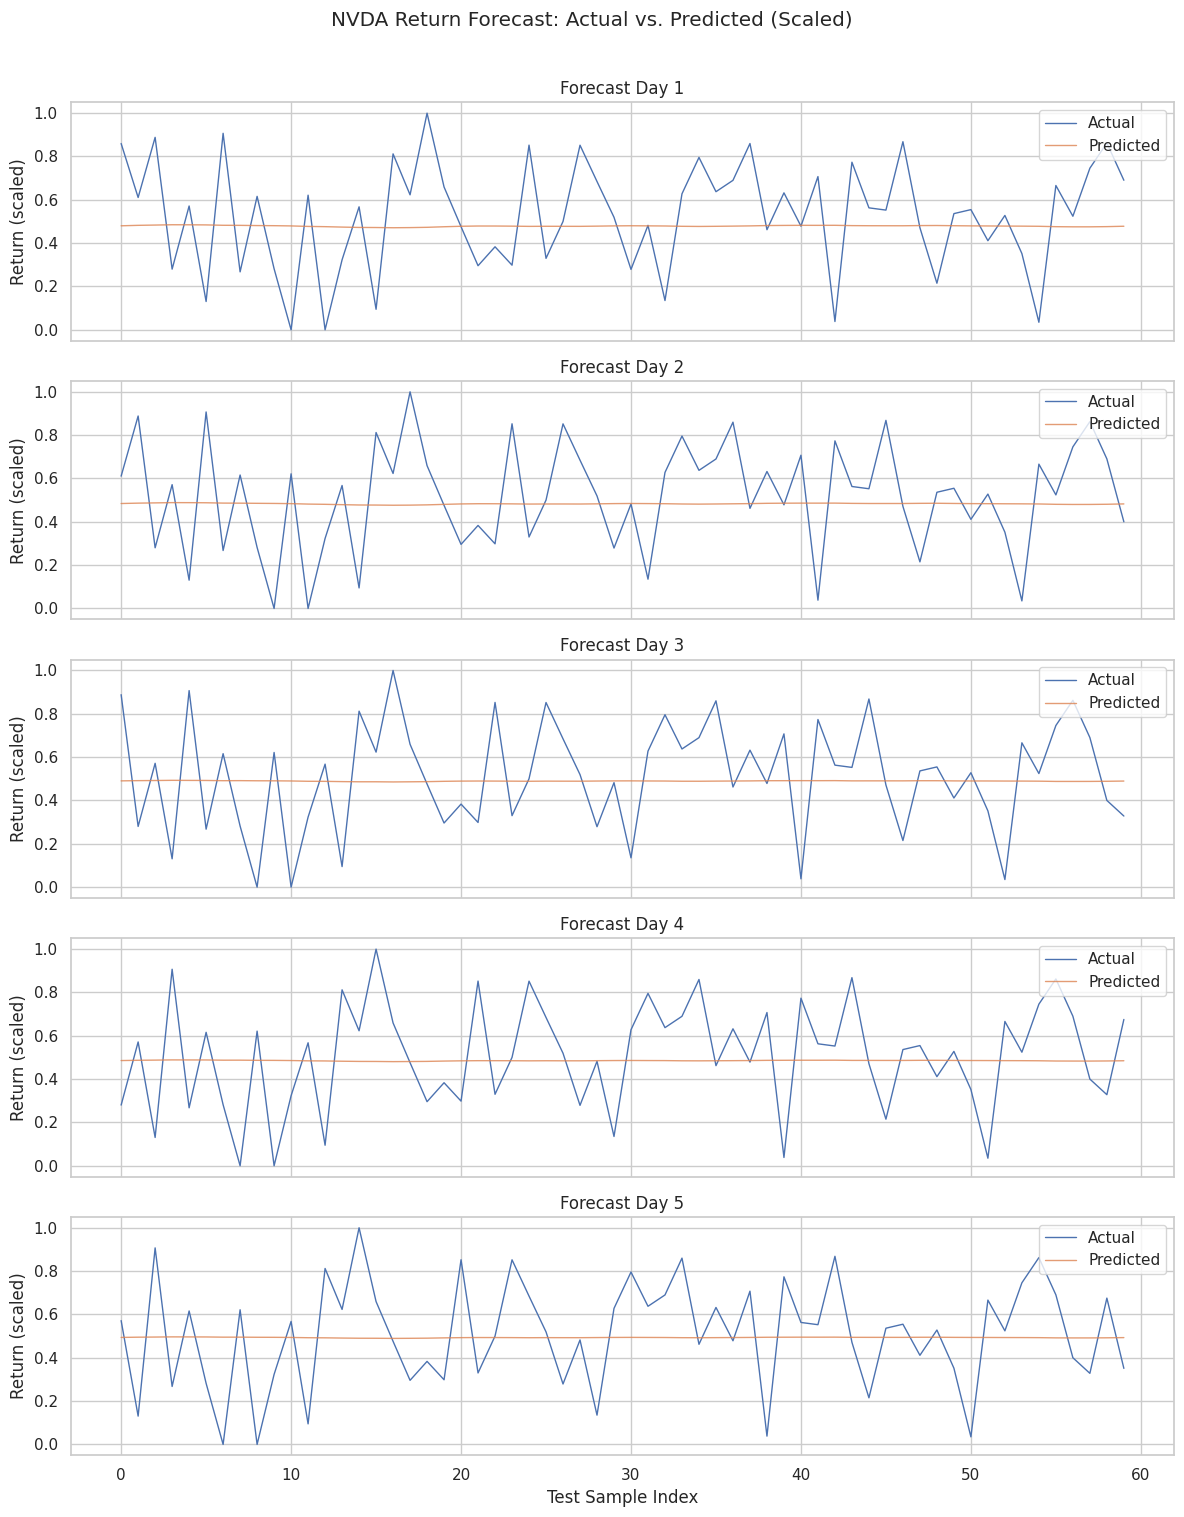

In [127]:
# ANSWER
# DONE: Using test data, plot the actual vs. predicted values for some subset of days. 
# Analyze results.



n_plot = min(60, len(actuals_stock))
fig, axes = plt.subplots(STOCK_HORIZON, 1, figsize=(12, 3 * STOCK_HORIZON), sharex=True)

for h in range(STOCK_HORIZON):
    axes[h].plot(actuals_stock[:n_plot, h], label="Actual",    linewidth=1.0)
    axes[h].plot(preds_stock[:n_plot, h],   label="Predicted", linewidth=1.0, alpha=0.8)
    axes[h].set_title(f"Forecast Day {h + 1}")
    axes[h].set_ylabel("Return (scaled)")
    axes[h].legend(loc="upper right")

axes[-1].set_xlabel("Test Sample Index")
plt.suptitle("NVDA Return Forecast: Actual vs. Predicted (Scaled)", y=1.01)
plt.tight_layout()
plt.show()



### Challenge 2 Reflection

**Q:** Would an MAE-minimizing model actually be useful for trading decisions? What are the limitations?

**Answer:**
<br>
No, it would not be useful here because minimizing mean absolute error (MAE) will cause the prediction to be like a naive average prediction (like a line of best fit) that is relatively straight. It is not able to accurately predict the direction/magnitude of the changes as it takes the average returns value each day. If there were negative returns, the averaged value could still be positive, giving the wrong signal to the trader. The forecast is not actionable.
<br>

## Challenge 3: Stacked LSTMs and Dropout Regularization

Deeper LSTMs can learn more complex sequence patterns, but they also overfit more easily. Dropout between layers is the primary regularization mechanism for stacked RNNs.

### Your task:

1. Train LSTMs with `rnn_num_layers ∈ {1, 2, 3, 4}` on IMDB, **without** inter-layer dropout.
2. Repeat all four depths with **inter-layer dropout = 0.3**.
3. Plot validation accuracy and training loss curves for all 8 configurations (4 depths × 2 dropout settings).
4. **Analysis:** Where does depth help? Where does it hurt? Does dropout mitigate the overfitting?

**A note on how to set inter-layer dropout with our engine:**
PyTorch's `nn.LSTM` accepts a `dropout` argument that applies dropout *between stacked layers* (it has no effect when `num_layers=1`). However, our engine's `ModelConfig.dropout` controls the *classifier head* dropout, not the LSTM's internal inter-layer dropout. Rather than restructuring the engine right now, use this workaround after calling `build_model()`:

```python
# Set the LSTM's inter-layer dropout directly (only meaningful when num_layers > 1)
if hasattr(model, 'rnn') and num_layers > 1:
    model.rnn.dropout = 0.3
```

This is not an ideal pattern — ideally the engine would expose this via `ModelConfig` — but it gets the job done for our experiments here.

In [130]:
# ANSWER
depths = [1, 2, 3, 4]
use_dropout_settings = [False, True]

if RUN_TRAINING_MODE == RunTrainingMode.FULL:
    num_epochs_c3 = 10
elif RUN_TRAINING_MODE == RunTrainingMode.QUICK:
    num_epochs_c3 = 5
else:
    num_epochs_c3 = 0

c3_results = {}  # key: (num_layers, use_dropout) -> {"train_loss": [...], "val_accuracy": [...]}

for num_layers in depths:
    for use_dropout in use_dropout_settings:
        label = f"layers={num_layers}, dropout={'0.3' if use_dropout else 'none'}"
        print(f"\n--- Training: {label} ---")

        cfg = ModelConfig(
            model_type=ModelType.TEXTRNN,
            vocab_size=len(imdb_vocab),
            embedding_dim=100,
            padding_idx=0,
            rnn_hidden_size=64,
            rnn_num_layers=num_layers,
            rnn_type="lstm",
            bidirectional=False,
            hidden_units=[64],
            dropout=[0.2],
            clip_grad_norm=1.0,
        )
        model = build_model(input_spec=None, num_outputs=2, config=cfg)

        # Apply inter-layer dropout workaround (no effect when num_layers == 1)
        if use_dropout and num_layers > 1:
            model.rnn.dropout = 0.3

        trainer_cfg = TrainerConfig(
            trainer_batch_size=64,
            evaluator_batch_size=256,
            learning_rate=1e-3,
            optimizer_name="adam",
            weight_decay=1e-5,
            device=accel_device,
            num_epochs=num_epochs_c3,
        )

        train_losses, val_accs = [], []

        with Trainer(
            model=model,
            optimizer=make_optimizer(model.parameters(), trainer_cfg),
            criterion=nn.CrossEntropyLoss(),
            config=trainer_cfg,
            run=None,
            metrics_config=MetricsConfig(task="multiclass", names=["accuracy", "loss"]),
        ) as trainer:
            for epoch in range(num_epochs_c3):
                train_m = trainer.train_one_epoch(imdb_train_loader)
                val_m   = trainer.validate(imdb_test_loader)
                train_losses.append(train_m["loss"])
                val_accs.append(val_m["accuracy"])
                print(f"  Epoch {epoch+1}: train_loss={train_m['loss']:.4f}  val_acc={val_m['accuracy']*100:.2f}%")

        c3_results[(num_layers, use_dropout)] = {
            "train_loss": train_losses,
            "val_accuracy": val_accs,
        }


--- Training: layers=1, dropout=none ---
  Epoch 1: train_loss=0.6674  val_acc=63.26%
  Epoch 2: train_loss=0.5553  val_acc=71.39%
  Epoch 3: train_loss=0.4288  val_acc=73.87%
  Epoch 4: train_loss=0.3256  val_acc=79.13%
  Epoch 5: train_loss=0.2515  val_acc=79.32%
  Epoch 6: train_loss=0.1820  val_acc=78.71%
  Epoch 7: train_loss=0.1326  val_acc=80.04%
  Epoch 8: train_loss=0.0868  val_acc=80.42%
  Epoch 9: train_loss=0.0499  val_acc=78.79%
  Epoch 10: train_loss=0.0448  val_acc=81.36%

--- Training: layers=1, dropout=0.3 ---
  Epoch 1: train_loss=0.6673  val_acc=65.02%
  Epoch 2: train_loss=0.5492  val_acc=75.08%
  Epoch 3: train_loss=0.4275  val_acc=66.27%
  Epoch 4: train_loss=0.3767  val_acc=78.29%
  Epoch 5: train_loss=0.2657  val_acc=79.04%
  Epoch 6: train_loss=0.1794  val_acc=80.70%
  Epoch 7: train_loss=0.1265  val_acc=79.84%
  Epoch 8: train_loss=0.0822  val_acc=79.74%
  Epoch 9: train_loss=0.0564  val_acc=81.96%
  Epoch 10: train_loss=0.0319  val_acc=80.74%

--- Training: 

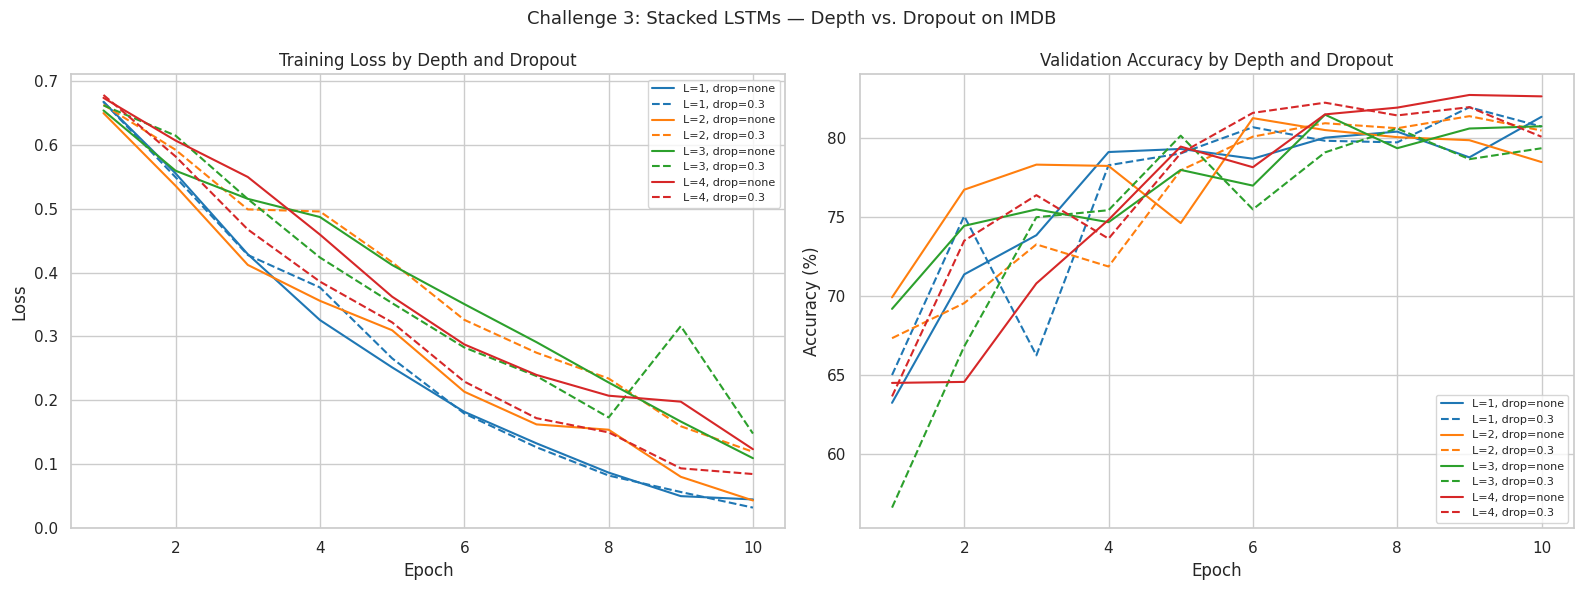

In [131]:
# ANSWER
# Visualize the results
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

colors     = {1: "#1f77b4", 2: "#ff7f0e", 3: "#2ca02c", 4: "#d62728"}
linestyles = {False: "-", True: "--"}  # solid = no dropout, dashed = with dropout

for (num_layers, use_dropout), history in c3_results.items():
    label  = f"L={num_layers}, drop={'0.3' if use_dropout else 'none'}"
    epochs = range(1, len(history["train_loss"]) + 1)

    axes[0].plot(epochs, history["train_loss"],
                color=colors[num_layers], linestyle=linestyles[use_dropout], label=label)
    axes[1].plot(epochs, [v * 100 for v in history["val_accuracy"]],
                color=colors[num_layers], linestyle=linestyles[use_dropout], label=label)

axes[0].set_title("Training Loss by Depth and Dropout")
axes[0].set_xlabel("Epoch")
axes[0].set_ylabel("Loss")
axes[0].legend(fontsize=8)

axes[1].set_title("Validation Accuracy by Depth and Dropout")
axes[1].set_xlabel("Epoch")
axes[1].set_ylabel("Accuracy (%)")
axes[1].legend(fontsize=8)

plt.suptitle("Challenge 3: Stacked LSTMs — Depth vs. Dropout on IMDB", fontsize=13)
plt.tight_layout()
plt.show()

### Challenge 3 Analysis

**Answer:**
<br>
We can see that the training loss of the stacked LSTMs with more layers and no dropout seemed to be higher than those with less layers (with/without dropout). This is surprising since I would assume the LSTMs with more layers would have lower training loss due to overfitting. This maybe due to the random nature of neural networks. However, we can also see that dropout usually led to higher training loss (except for L4), which makes sense. In terms of validation accuracy, we can see the dropout only improved accuracy for L=2. This may also be due to the random nature of neural networks.
<br>

## Challenge 4: Seq2Seq Multi-Step Forecasting with an LSTM

In hw09 Challenge 3, you used a **direct multi-output** strategy: one forward pass produces all future values at once. An alternative is the **sequence-to-sequence (seq2seq)** approach: an encoder LSTM reads the input, and a decoder LSTM **autoregressively** generates the output one step at a time.

**Background:** The sequence-to-sequence (seq2seq) architecture was introduced in 2014 for neural machine translation and revolutionized how we handle variable-length input-output mappings. Unlike direct multi-output models that predict all future values in parallel, seq2seq uses an **encoder-decoder** framework: the encoder compresses the input sequence into a fixed-size context vector (the final hidden state), and the decoder autoregressively generates the output sequence one step at a time, conditioned on that context.

**What do we mean by autoregressive?** In an autoregressive model, each output is generated one at a time and each new prediction depends on the previously generated outputs. For example, to predict 5 future values, the decoder first predicts step 1, then uses that prediction as input to predict step 2, then uses step 2's prediction to predict step 3, and so on. This is in contrast to the direct multi-output approach where all 5 predictions are made simultaneously in a single forward pass, which is what we've been doing so far.

This architecture is foundational to modern NLP. It directly led to the development of **attention mechanisms** (which allow the decoder to "look back" at all encoder states, not just the final one) and ultimately to **transformers** (which replace RNNs with self-attention). Understanding seq2seq now will make the topic of **attention mechanisms** next week much more intuitive. It'll give you a preview of the encoder-decoder architecture that underpins transformers, and give you concrete intuition for why attention mechanisms were invented. 

**Further reading:** 
* [Sequence to Sequence Learning with Neural Networks (Sutskever et al., 2014)](https://arxiv.org/abs/1409.3215)
* [seq2seq model - GeekForGeeks](https://www.geeksforgeeks.org/machine-learning/seq2seq-model-in-machine-learning/)
* [Translation with a seq2seq model - PyTorch tutorials](https://docs.pytorch.org/tutorials/intermediate/seq2seq_translation_tutorial.html)

### Your task:

There are two different approaches you could take to training a Seq2Seq model. 
* Create two classes - one representing the encoder, and one the decoder
* Create one class that encapsulates both the encoder and decoder. 

You are going to follow the one-class approach:<br>
1. Implement a class called `Seq2SeqForecaster(nn.Module)`. It should encapsulate the following:
   - A constructor that takes `input_size`, `hidden_size`, `num_layers`, and `forecast_horizon` as parameters.
   - The constructor should encapsulate:
      - An **encoder** LSTM that reads the input window and produces a final hidden state
      - A **decoder** LSTM that takes the encoder's final hidden state and autoregressively generates `forecast_horizon` output values
   - At each decoder step, the previous prediction is fed as the next input
2. Train on the UCI Appliances Energy dataset
3. Compare MAE to the direct multi-output strategy (retrain an `RNNModel(num_outputs=5)` for comparison)
4. **Analysis:** When might seq2seq be better than direct multi-output?

In [ ]:
class Seq2SeqForecaster(nn.Module):
    """Encoder-decoder LSTM for multi-step time series forecasting.

    The encoder reads a sequence of historical values and produces a final
    hidden state. The decoder autoregressively generates future values,
    feeding each prediction as the next input.

    Args:
        input_size: Number of features per time step (1 for univariate).
        hidden_size: Hidden state dimensionality for both encoder and decoder.
        num_layers: Number of stacked LSTM layers.
        forecast_horizon: Number of future steps to predict.
    """

    def __init__(self, input_size: int, hidden_size: int, num_layers: int, forecast_horizon: int):
        super().__init__()
        self.forecast_horizon = forecast_horizon
        self.hidden_size = hidden_size
        self.config = ModelConfig(
            model_type=ModelType.RNN,
            rnn_hidden_size=hidden_size,
            rnn_num_layers=num_layers,
            rnn_type="lstm"
        )

        # Create encoder LSTM (reads the input window)
        self.encoder = nn.LSTM(
            input_size=input_size,
            hidden_size=self.config.rnn_hidden_size,
            num_layers=self.config.rnn_num_layers,
            bidirectional=self.config.bidirectional,
            batch_first=True,
        )

        # Create decoder LSTM (generates predictions step by step)
        self.decoder = nn.LSTM(
            input_size=input_size,
            hidden_size=self.config.rnn_hidden_size,
            num_layers=self.config.rnn_num_layers,
            bidirectional=self.config.bidirectional,
            batch_first=True,
        )

        # Linear layer to map decoder hidden state to a single value
        self.output_layer = _construct_fc_layers(start_layer_size=hidden_size, config=self.config, num_outputs=1)

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        """Forward pass.

        Args:
            x: Input tensor of shape (batch, seq_len, input_size).

        Returns:
            Predictions of shape (batch, forecast_horizon).
        """
        # Encode the input sequence
        _, (h, c) = self.encoder(x)

        # Autoregressive decoding
        # Start with the last known value as the first decoder input
        decoder_input = x[:, -1:, :]  # (batch, 1, input_size)

        predictions = []
        for _ in range(self.forecast_horizon):
            # One decoder step; initialize hidden state from encoder
            output, (h, c) = self.decoder(decoder_input, (h, c)) # output has size (batch, 1, hidden_size)

            # Map to predicted value
            pred = self.output_layer(output.squeeze(1))  # (batch, 1)
            predictions.append(pred)

            # Feed prediction back as next input
            decoder_input = pred.unsqueeze(1)  # (batch, 1, input_size)

        return torch.cat(predictions, dim=1)  # (batch, forecast_horizon)

In [134]:
# ANSWER
# DONE: Train the seq2seq model on the energy dataset with forecast_horizon=5
from lantern.model import Seq2SeqForecaster

C4_FORECAST_HORIZON = 5
C4_SEQ_LEN = 200
C4_BATCH_SIZE = 64

train_ts_c4 = TimeSeriesDataset(train_scaled, seq_len=C4_SEQ_LEN, forecast_horizon=C4_FORECAST_HORIZON)
val_ts_c4   = TimeSeriesDataset(val_scaled,   seq_len=C4_SEQ_LEN, forecast_horizon=C4_FORECAST_HORIZON)
test_ts_c4  = TimeSeriesDataset(test_scaled,  seq_len=C4_SEQ_LEN, forecast_horizon=C4_FORECAST_HORIZON)

train_loader_c4 = DataLoader(train_ts_c4, batch_size=C4_BATCH_SIZE, shuffle=True)
val_loader_c4   = DataLoader(val_ts_c4,   batch_size=C4_BATCH_SIZE, shuffle=False)
test_loader_c4  = DataLoader(test_ts_c4,  batch_size=C4_BATCH_SIZE, shuffle=False)

s2s_model = Seq2SeqForecaster(input_size=1, hidden_size=64, num_layers=2, forecast_horizon=C4_FORECAST_HORIZON)
s2s_trainer_config = TrainerConfig(
    learning_rate=1e-3,
    optimizer_name="adam",
    weight_decay=1e-5,
    device=accel_device,
    num_epochs=20,
    trainer_batch_size=C4_BATCH_SIZE,
    evaluator_batch_size=C4_BATCH_SIZE,
    early_stopping_patience=None,
)

with Trainer(
    model=s2s_model,
    optimizer=make_optimizer(s2s_model.parameters(), s2s_trainer_config),
    criterion=nn.MSELoss(),
    config=s2s_trainer_config,
    run=None,
    metrics_config=MetricsConfig(task="regression", names=["mae"]),
) as trainer:
    trainer.fit(train_loader_c4, val_loader_c4)



Epoch 0:
Train Mae=0.0549  Val Mae=0.0291
--> New best checkpoint saved: ./checkpoints/best.pt
--> Also saving as last checkpoint: ./checkpoints/last.pt
Epoch 1:
Train Mae=0.0451  Val Mae=0.0493
Epoch 2:
Train Mae=0.0444  Val Mae=0.0353
Epoch 3:
Train Mae=0.0430  Val Mae=0.0357
Epoch 4:
Train Mae=0.0422  Val Mae=0.0289
--> Saving checkpoint: ./checkpoints/last.pt
Epoch 5:
Train Mae=0.0419  Val Mae=0.0271
Epoch 6:
Train Mae=0.0419  Val Mae=0.0332
Epoch 7:
Train Mae=0.0417  Val Mae=0.0298
Epoch 8:
Train Mae=0.0420  Val Mae=0.0367
Epoch 9:
Train Mae=0.0413  Val Mae=0.0276
--> Saving checkpoint: ./checkpoints/last.pt
Epoch 10:
Train Mae=0.0416  Val Mae=0.0285
Epoch 11:
Train Mae=0.0414  Val Mae=0.0289
Epoch 12:
Train Mae=0.0412  Val Mae=0.0272
Epoch 13:
Train Mae=0.0416  Val Mae=0.0274
Epoch 14:
Train Mae=0.0417  Val Mae=0.0373
--> Saving checkpoint: ./checkpoints/last.pt
Epoch 15:
Train Mae=0.0417  Val Mae=0.0282
Epoch 16:
Train Mae=0.0412  Val Mae=0.0330
Epoch 17:
Train Mae=0.0416  Val M

In [135]:
# ANSWER
# DONE: Compare seq2seq to direct multi-output
# Train a direct model using RNNModel(num_outputs=5)
direct_config = ModelConfig(
      model_type=ModelType.RNN,
      rnn_hidden_size=64,
      rnn_num_layers=2,
      rnn_type="lstm",
      hidden_units=[],
      dropout=[],
      clip_grad_norm=1.0,
  )
direct_model = build_model(input_spec=1, num_outputs=C4_FORECAST_HORIZON, config=direct_config)
direct_trainer_config = TrainerConfig(
    learning_rate=1e-3,
    optimizer_name="adam",
    weight_decay=1e-5,
    device=accel_device,
    num_epochs=20,
    trainer_batch_size=C4_BATCH_SIZE,
    evaluator_batch_size=C4_BATCH_SIZE,
    early_stopping_patience=None,
)

with Trainer(
    model=direct_model,
    optimizer=make_optimizer(direct_model.parameters(), direct_trainer_config),
    criterion=nn.MSELoss(),
    config=direct_trainer_config,
    run=None,
    metrics_config=MetricsConfig(task="regression", names=["mae"]),
) as trainer:
    trainer.fit(train_loader_c4, val_loader_c4)





Epoch 0:
Train Mae=0.0512  Val Mae=0.0402
--> New best checkpoint saved: ./checkpoints/best.pt
--> Also saving as last checkpoint: ./checkpoints/last.pt
Epoch 1:
Train Mae=0.0449  Val Mae=0.0302
Epoch 2:
Train Mae=0.0428  Val Mae=0.0405
Epoch 3:
Train Mae=0.0416  Val Mae=0.0271
Epoch 4:
Train Mae=0.0413  Val Mae=0.0295
--> Saving checkpoint: ./checkpoints/last.pt
Epoch 5:
Train Mae=0.0410  Val Mae=0.0322
Epoch 6:
Train Mae=0.0413  Val Mae=0.0285
Epoch 7:
Train Mae=0.0411  Val Mae=0.0316
Epoch 8:
Train Mae=0.0410  Val Mae=0.0273
Epoch 9:
Train Mae=0.0410  Val Mae=0.0339
--> Saving checkpoint: ./checkpoints/last.pt
Epoch 10:
Train Mae=0.0408  Val Mae=0.0336
Epoch 11:
Train Mae=0.0407  Val Mae=0.0315
Epoch 12:
Train Mae=0.0408  Val Mae=0.0291
Epoch 13:
Train Mae=0.0408  Val Mae=0.0341
Epoch 14:
Train Mae=0.0410  Val Mae=0.0299
--> Saving checkpoint: ./checkpoints/last.pt
Epoch 15:
Train Mae=0.0410  Val Mae=0.0335
Epoch 16:
Train Mae=0.0407  Val Mae=0.0347
Epoch 17:
Train Mae=0.0409  Val M

In [136]:
# DONE: Evaluate both on test set
s2s_model.eval()
direct_model.eval()

s2s_preds, direct_preds, all_actuals = [], [], []

with torch.no_grad():
    for x_batch, y_batch in test_loader_c4:
        x_batch = x_batch.to(accel_device)
        s2s_preds.append(s2s_model(x_batch).cpu().numpy())
        direct_preds.append(direct_model(x_batch).cpu().numpy())
        all_actuals.append(y_batch.numpy())

s2s_preds    = np.concatenate(s2s_preds)
direct_preds = np.concatenate(direct_preds)
actuals_c4   = np.concatenate(all_actuals)

s2s_mae    = np.mean(np.abs(s2s_preds    - actuals_c4))
direct_mae = np.mean(np.abs(direct_preds - actuals_c4))




print(f"Seq2Seq 5-Step MAE:  {s2s_mae:.6f}")
print(f"Direct 5-Step MAE:   {direct_mae:.6f}")

Seq2Seq 5-Step MAE:  0.031709
Direct 5-Step MAE:   0.037821


### Challenge 4 Analysis

**Answer:**
<br>
The Seq2Seq had a lower 5-step MAE than the direct one since the direct approach predicts all 5-steps simultaneously from a single fixed vector, treating each future step independently. The Seq2Seq, on the other hand, maintains a running hidden state, capturing the relationship of each prediction being conditioned on all previous predictions AND the evolving decoder state. One thing to be wary about is that Seq2Seq also can lead to compounding of wrong predictions since later predictions are based on earlier predictions, which may be wrong.
<br>

## Challenge 5: [ADVANCED] Sentiment Analysis on a More Challenging Dataset

IMDB reviews are relatively short and binary. Can your gated models handle longer, more nuanced text?

### Your task:

1. Load the **AG News** dataset using `get_hf_text_dataset("ag_news", ...)` (already supported in the engine). This has 4 classes: World, Sports, Business, Science/Technology.
2. Train three models: unidirectional LSTM, bidirectional LSTM, and GRU
3. Compare accuracy and parameter count
4. **Analysis:** What patterns in this dataset benefit most from bidirectionality? Does the 4-class setting change the architecture comparison?

In [137]:
# ANSWER
# Load AG News — 4-class news topic classification
# Subsample to keep training fast (120k full train is large)
ag_train_ds, ag_test_ds, ag_vocab = get_hf_text_dataset(
    "ag_news",
    max_vocab_size=25000,
    train_subset_fn=lambda ds: ds.select(range(20000)),
    test_subset_fn=lambda ds: ds.select(range(4000)),
)

print(f"Vocabulary size:   {len(ag_vocab)}")
print(f"Training samples:  {len(ag_train_ds)}")
print(f"Test samples:      {len(ag_test_ds)}")

ag_train_loader, ag_test_loader, _ = get_dataloaders(
    ag_train_ds, ag_test_ds,
    train_batch_size=64,
    eval_batch_size=256,
    collate_fn=text_collate_fn,
  )







README.md: 0.00B [00:00, ?B/s]

data/train-00000-of-00001.parquet:   0%|          | 0.00/18.6M [00:00<?, ?B/s]

data/test-00000-of-00001.parquet:   0%|          | 0.00/1.23M [00:00<?, ?B/s]

Generating train split:   0%|          | 0/120000 [00:00<?, ? examples/s]

Generating test split:   0%|          | 0/7600 [00:00<?, ? examples/s]

Vocabulary size:   22535
Training samples:  20000
Test samples:      4000


In [139]:
# ANSWER
# Train three models and compare

if RUN_TRAINING_MODE == RunTrainingMode.FULL:
    num_epochs_c5 = 10
elif RUN_TRAINING_MODE == RunTrainingMode.QUICK:
    num_epochs_c5 = 5
else:
    num_epochs_c5 = 0

ag_trainer_config = TrainerConfig(
    trainer_batch_size=64,
    evaluator_batch_size=256,
    learning_rate=1e-3,
    optimizer_name="adam",
    weight_decay=1e-5,
    device=accel_device,
    num_epochs=num_epochs_c5,
)

c5_configs = {
    "lstm_uni": ModelConfig(
        model_type=ModelType.TEXTRNN,
        vocab_size=len(ag_vocab),
        embedding_dim=100,
        padding_idx=0,
        rnn_hidden_size=128,
        rnn_num_layers=1,
        rnn_type="lstm",
        bidirectional=False,
        hidden_units=[64],
        dropout=[0.3],
    ),
    "lstm_bi": ModelConfig(
        model_type=ModelType.TEXTRNN,
        vocab_size=len(ag_vocab),
        embedding_dim=100,
        padding_idx=0,
        rnn_hidden_size=128,
        rnn_num_layers=1,
        rnn_type="lstm",
        bidirectional=True,
        hidden_units=[64],
        dropout=[0.3],
    ),
    "gru_uni": ModelConfig(
        model_type=ModelType.TEXTRNN,
        vocab_size=len(ag_vocab),
        embedding_dim=100,
        padding_idx=0,
        rnn_hidden_size=128,
        rnn_num_layers=1,
        rnn_type="gru",
        bidirectional=False,
        hidden_units=[64],
        dropout=[0.3],
    ),
}

c5_results = {}
for name, cfg in c5_configs.items():
    print(f"\n--- Training: {name} ---")
    model = build_model(input_spec=1, num_outputs=4, config=cfg)
    total_params, _ = model.num_parameters()
    print(f"Parameters: {total_params:,}")

    with Trainer(
        model=model,
        optimizer=make_optimizer(model.parameters(), ag_trainer_config),
        criterion=nn.CrossEntropyLoss(),
        config=ag_trainer_config,
        metrics_config=MetricsConfig(task="multiclass", names=["accuracy", "loss"]),
        run=None,
    ) as trainer:
        results = trainer.fit(ag_train_loader, ag_test_loader)

    c5_results[name] = {
        "val_accuracy": results.get("val_accuracy", float("nan")),
        "val_loss": results.get("val_loss", float("nan")),
        "total_params": total_params,
    }

print("\n--- Challenge 5 Summary ---")
print(f"{'Model':<12} {'Val Accuracy':>14} {'Val Loss':>14} {'Parameters':>12}")
print("-" * 40)
for name, r in c5_results.items():
    print(f"{name:<12} {r['val_accuracy']:>14.4f} {r['val_loss']:>14.4f} {r['total_params']:>12,}")













--- Training: lstm_uni ---
Parameters: 2,379,776
Epoch 0:
Train Accuracy=53.06%  Val Accuracy=69.55%
Train Loss=1.0229  Val Loss=0.7560
--> New best checkpoint saved: ./checkpoints/best.pt
--> Also saving as last checkpoint: ./checkpoints/last.pt
Epoch 1:
Train Accuracy=79.49%  Val Accuracy=77.38%
Train Loss=0.5638  Val Loss=0.6098
--> New best checkpoint saved: ./checkpoints/best.pt
--> Also saving as last checkpoint: ./checkpoints/last.pt
Epoch 2:
Train Accuracy=86.95%  Val Accuracy=82.30%
Train Loss=0.3914  Val Loss=0.5201
--> New best checkpoint saved: ./checkpoints/best.pt
--> Also saving as last checkpoint: ./checkpoints/last.pt
Epoch 3:
Train Accuracy=90.08%  Val Accuracy=82.35%
Train Loss=0.3076  Val Loss=0.5264
Epoch 4:
Train Accuracy=92.39%  Val Accuracy=83.70%
Train Loss=0.2411  Val Loss=0.5386
--> Saving checkpoint: ./checkpoints/last.pt
Epoch 5:
Train Accuracy=93.71%  Val Accuracy=75.43%
Train Loss=0.2175  Val Loss=0.8579
Epoch 6:
Train Accuracy=93.14%  Val Accuracy=83.45

### Challenge 5 Analysis

**Answer:**
<br>
We can see that the bidirectional LSTM does not provide better accuracy/loss compared to the unidirectional LSTM. The unidirectional GRU is also not as performant as the LSTMs, which indicate that the 4-gate architecture captured the patterns in sentiments better than the coupled forget/input gate in GRUs. The number of parameters are quite similar because the embedding layer, where the vocab size of 22,535 and embedding dimension of 100 dominate the parameter count for the RNN portion.
<br>

In [ ]:
show_section("Career Survey")

# Career Survey

Please read the following article from TechCrunch, which appeared on March 25, 2026: 

[**The AI skills gap is here, says AI company, and power users are pulling ahead**](https://techcrunch.com/2026/03/25/the-ai-skills-gap-is-here-says-ai-company-and-power-users-are-pulling-ahead/)

This article discusses emerging evidence that AI is not yet replacing jobs at scale, but is already changing *who* gains an advantage in the labor market, with “power users” of AI tools pulling ahead.  It raises questions about inequality, geography, and what it means to build a resilient career in an AI-mediated workplace. 

After reading, choose **one** of the following prompts and respond in a short reflection (1–2 thoughtful paragraphs, no AI please):

1. **Power users and your career**<br>
The article argues that “power users” who learn to use tools like Claude as a thought partner are pulling ahead, even before major displacement shows up in unemployment data.  In the specific career path you’re currently considering, what would “power user of AI” actually look like day to day, and what concrete habits could you start building to move in that direction (if that was something that you thought was right for you)?

**ANSWER:**
<br>
In my career path, a power user of AI is someone who would be actively using AI coding assistants like Claude Code to generate code and ship quickly. To become proficient at this, I would need to actively learn how to vet AI generate code quickly and identify modes of failure. This will ensure that the code that I am shipping does not bring down any essential services but also allow me to ship a lot more code than if I were to manually write everything down. Understanding how to prompt the AI coding assistants would also be critical as giving the LLM proper instructions and context can boost its performance.
<br>

2. **Inequality, geography, and responsibility**<br>
Anthropic’s report suggests that AI is used more intensely in high‑income regions and knowledge‑worker hubs, which may amplify existing inequalities as power users pull further ahead.  How does this geographic and skills concentration shape the way you think about where you work? How does it affect your own responsibility to share or gatekeep AI skills?

**ANSWER:**
<br>
<br>
<br>


3. **Entry-level jobs and strategy**  
Dario Amodei warns that AI could wipe out up to half of entry‑level white‑collar roles within five years, even though Anthropic currently sees “no real signs of AI-related job loss yet.”  If that tension is real, how should it influence your strategy for internships, first jobs, and lifelong learning? What are you doing differently compared with what students from a decade ago were doing when AI had no impact on entry-level jobs? 

**ANSWER:**
<br>
<br>
<br>



**ANSWER:**
<br>
<br>




In [ ]:
show_section("Society")


# Society

Article: [**Cognitive manipulation and AI will shape disinformation in 2026.**](https://www.weforum.org/stories/2026/03/how-cognitive-manipulation-and-ai-will-shape-disinformation-in-2026/)

This article highlights how advances in **AI** and synthetic media are turning mis- and disinformation into a systemic global risk that can destabilize democracies, amplify polarization, and erode trust in core institutions. It shows that AI systems are now used not just to generate plausible fake content, but to micro-target individuals with emotionally charged narratives that exploit psychological profiling and the engagement-driven incentives of major platforms. 

Choose one of the prompts below, and write 100-200 reflection in your own words:

1. **Cognitive manipulation and you**<br>
The article describes how AI-powered disinformation campaigns use psychological profiling, emotional triggers (e.g., fear, anger, anxiety), and platform engagement incentives to manipulate behavior and beliefs at scale. Explain how these mechanisms intersect with the models and systems you are learning in this course (e.g., recommender systems, sequence models, generative models), and discuss one concrete way that your own future work as an AI practitioner could either mitigate or unintentionally amplify such cognitive manipulation. 

**ANSWER:**
<br>
One concrete way that my future work could mitigate such cognitive manipulation would be to make sure that AI generated content is labeled appropriately. It would be very difficult to verify this but advocating for this would be helpful. For instance, creating some sort of system that can fact-check information that is spread on social media could be helpful. I am not sure how this would look like, but it could help people verify information. We could also make sure to keep the recommender systems in check, ensuring that they do not suggest misinformation to people who are particularly vulnerable to such news. However, the risk with this is that users can also generate AI content to circumvent or take advantage of such systems, further amplifying cognitive manipulation and the dissemination of false information.
<br>



2. **Resilience, governance, and technical design**<br>
The authors argue that resilience to disinformation depends on three pillars: *verification*, *deliberation*, and *accountability*, and they point to tools like deepfake detection, distribution-pattern analysis, and regulatory measures such as Article 50 of the EU AI Act, which mandates labelling of AI-generated and deepfake content from August 2026. In 100–200 words, propose a technical or socio-technical intervention (a model, system design choice, UX pattern, or policy integration) that could strengthen at least one of these pillars, and critically assess one limitation or unintended consequence of your proposal in real-world deployment. 

**ANSWER:**
<br>
<br>
<br>





# AI Usage Disclosure

**IDE or browser-based environment used:** VSCode

**AI tools used:** Claude

**Short reflection:**
How did you use AI this week? Did it help you understand gate equations? Debug your training loop? Compare architectures? Be specific about what worked well and what didn't.

I used AI for syntax and typing up code not directly related to neural networks like plotting.

**AI Chat Dialogs:**
(Paste relevant snippets here - particularly any that helped you understand conceptual questions or debug code)
<br>

1. 
```
Can you fill out Step B1.2 in the jupyter notebook                                                                                                                                            

  Searched for 1 pattern, read 1 file (ctrl+o to expand)

⏺ Bash(sed -n '1498,1560p' "/Users/changminbark/Library/CloudStorage/GoogleDrive-cb073@bucknell.edu/My Drive/2026 SS/CSCI357/csci357_2026sp/notebooks/10-LSTM.ipynb")
  ⎿      {
           "cell_type": "markdown",
           "id": "0c27f57f",
     … +61 lines (ctrl+o to expand)

⏺ Now let me check what variables are available from B1.1:

⏺ Bash(sed -n '1430,1500p' "/Users/changminbark/Library/CloudStorage/GoogleDrive-cb073@bucknell.edu/My Drive/2026 SS/CSCI357/csci357_2026sp/notebooks/10-LSTM.ipynb")
  ⎿          "## Section B1: Dataset Setup\n",
             "\n",
             "In hw09, we used a synthetic sine wave. This week, we move to real-world data: the **UCI Appliances Energy Prediction** dataset (ID 374). Information about the dataset can b
     … +32 lines (ctrl+o to expand)

⏺ Now I have all the context I need. The cell needs to plot y_energy as a time series. Let me fill it in:
  ⎿  Updated cell bdcb0359:
         1 # ANSWER
         2 # Plot the raw y_energy series. Note trends, seasonality, and noise.
         3
         4 fig, axes = plt.subplots(2, 1, figsize=(14, 7))
         5
         6 # Full series
         7 axes[0].plot(y_energy, linewidth=0.5, color="steelblue")
         8 axes[0].set_title("Appliances Energy Consumption — Full Series")
         9 axes[0].set_xlabel("Time Step (10-min intervals)")
        10 axes[0].set_ylabel("Energy (Wh)")
        11
        12 # First 2016 steps (~2 weeks) for a closer look at short-term patter
           ns
        13 axes[1].plot(y_energy[:2016], linewidth=0.8, color="steelblue")
        14 axes[1].set_title("Appliances Energy Consumption — First 2 Weeks")
        15 axes[1].set_xlabel("Time Step (10-min intervals)")
        16 axes[1].set_ylabel("Energy (Wh)")
        17
        18 plt.tight_layout()
        19 plt.show()
        20
        21 print(f"Total samples : {len(y_energy):,}")
        22 print(f"Min  : {y_energy.min():.1f} Wh")
        23 print(f"Max  : {y_energy.max():.1f} Wh")
        24 print(f"Mean : {y_energy.mean():.1f} Wh")
        25 print(f"Std  : {y_energy.std():.1f} Wh")

⏺ Done. The cell plots two views of y_energy:
  - Full series — the entire ~19k time steps at low linewidth to show macro structure.
  - First 2 weeks — a zoomed-in view of the first 2,016 steps (~2 weeks at 10-min intervals) to reveal daily/weekly periodicity.

  It also prints summary stats (min, max, mean, std) to support the reflective exercise that follows.
```



# Clean shutdown for Colab

In [ ]:
# Disconnect the runtime if in Colab
if IN_COLAB:
    from google.colab import runtime
    print("Disconnecting runtime...")
    runtime.unassign()
else:
    print("Not running in Colab, skipping disconnect.")